In [3]:
import torch
import torch.optim.lr_scheduler

# Monkey patch: Alias the old _LRScheduler to the new LRScheduler expected by Pyro
if not hasattr(torch.optim.lr_scheduler, "LRScheduler"):
    torch.optim.lr_scheduler.LRScheduler = torch.optim.lr_scheduler._LRScheduler

# Now import spateo
#import spateo as spt
import scanpy as sc
import numpy as np
import numpy as np
#import spateo as spt
import torch
import scanpy as sc
import scvelo as scv
import anndata as ad
import pandas as pd

In [4]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.pyplot import rc_context
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.cm import ScalarMappable
import matplotlib.ticker as ticker

In [5]:
import scipy.sparse as sp
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
import torch
import torch.nn.functional as F
import torch.optim as optim
import torch.nn as nn
import scvelo as scv
from sklearn.decomposition import PCA
from utils import seed_everything, load_data, sigmoid_gumbel_sample, get_logger, makedirs, count_parameters
from parse import parser
from model import build_model_tabular, set_cnf_options
from lib.regularization import create_regularization_fns
from train import pred_train, graph_discov
from visualize import plot_output, plot_causal_matrix
import os
from sklearn.neighbors import kneighbors_graph

In [6]:
import numpy as np
import torch
import random

def fix_all_seeds(seed=42):
    """固定所有随机种子，确保结果可复现"""
    # 固定numpy种子
    np.random.seed(seed)
    # 固定torch CPU种子
    torch.manual_seed(seed)
    # 固定torch GPU种子（若使用GPU）
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        # 禁用GPU的不确定性操作
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    # 固定python原生随机种子
    random.seed(seed)

# 调用函数固定种子（每次运行前都要执行）
fix_all_seeds(seed=42)

## load data

In [7]:
#adata1 = spt.read_h5ad('/media/lenovo/A06B2FA1620B6FCB/pythonProject/data/Development.h5ad')

In [8]:
#adata1

In [9]:
adata= sc.read_h5ad('/home/lenovo/jora/data/R5_filtered_latent.h5ad')

In [10]:
#adata_ref= spt.read_h5ad('/media/lenovo/A06B2FA1620B6FCB/pythonProject/data/DevelopmentTime_aligned.h5ad')

In [168]:
adata

AnnData object with n_obs × n_vars = 46202 × 16379
    obs: 'CellID', 'spatial_leiden_e30_s8', 'Batch', 'cell_id', 'seurat_clusters', 'inj_uninj', 'D_V', 'Annotation', 'time', 'Time', 'cell_growth', 'time_batch'
    var: 'Gene', 'var_names_new'
    uns: 'Annotation_colors', 'Injury_10DPI_rep1_SS200000147BL_B5', 'Injury_15DPI_rep4_FP200000266TR_E4', 'Injury_20DPI_rep2_SS200000147BL_B4', 'Injury_2DPI_rep1_SS200000147BL_D5', 'Injury_30DPI_rep2_FP200000264BL_A6', 'Injury_5DPI_rep1_SS200000147BL_D2', 'Injury_60DPI_rep3_FP200000264BL_A6', 'Injury_control_FP200000239BL_E3', 'angle_dict', 'transformation_parameters', 'time_batch_colors'
    obsm: 'X_latent', 'X_pca', 'X_spatial', 'X_spatial_aligned', 'spatial', 'spatial_aligned'
    layers: 'counts'

时间点: [2, 5, 10, 15, 20]


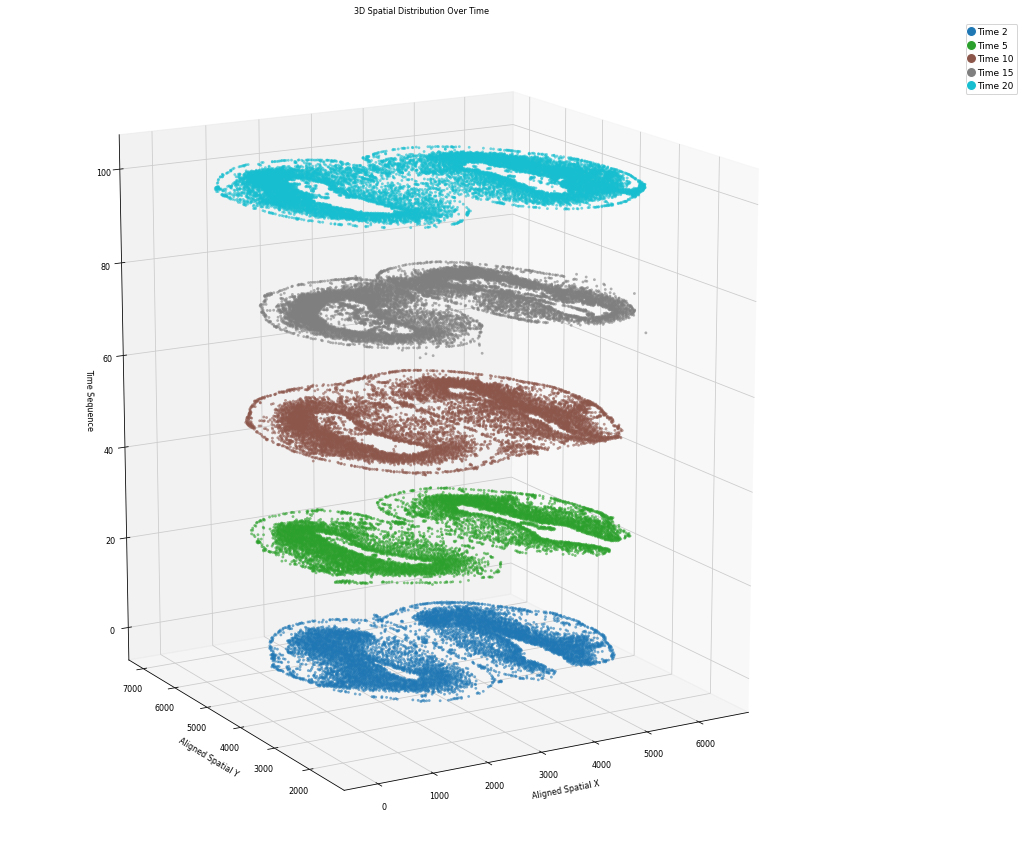

In [169]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# 获取时间和细胞类型信息
if 'Time' in adata.obs.columns:
    time_points = sorted(adata.obs['Time'].unique())
else:
    time_points = sorted(adata.obs['time'].unique())

print(f"时间点: {time_points}")

# 为每个时间点设置不同的颜色
time_colors = plt.cm.tab10(np.linspace(0, 1, len(time_points)))  # 使用tab10颜色映射

# 使用对齐后的空间坐标
if 'spatial_aligned' in adata.obsm:
    spatial_coords = adata.obsm['spatial_aligned']
else:
    spatial_coords = adata.obsm['spatial']

# 为每个时间点计算细胞密度
for i, time_point in enumerate(time_points):
    # 筛选该时间点的细胞
    if 'Time' in adata.obs.columns:
        time_mask = adata.obs['Time'] == time_point
    else:
        time_mask = adata.obs['time'] == time_point
    
    time_indices = np.where(time_mask)[0]
    
    if len(time_indices) == 0:
        continue
    
    # 提取该时间点的所有细胞（不再按细胞类型分组）
    x_coords = spatial_coords[time_indices, 0]
    y_coords = spatial_coords[time_indices, 1]
    z_coords = np.full_like(x_coords, i * 25)  # 每个时间点在z轴上偏移
    
    # 绘制该时间点的所有细胞
    ax.scatter(x_coords, y_coords, z_coords,
               color=time_colors[i],  # 使用时间点颜色
               label=f'Time {time_point}',
               alpha=0.6,
               s=8,
               edgecolors='none')

# 设置坐标轴
ax.set_xlabel('Aligned Spatial X')
ax.set_ylabel('Aligned Spatial Y')
ax.set_zlabel('Time Sequence')

# 设置视角
ax.view_init(elev=15, azim=-120)  # 调整视角

# 创建图例 - 现在显示时间点
legend_elements = []
for i, time_point in enumerate(time_points):
    legend_elements.append(Line2D([0], [0], marker='o', color='w',
                                  markerfacecolor=time_colors[i],
                                  markersize=10, label=f'Time {time_point}'))

ax.legend(handles=legend_elements, bbox_to_anchor=(1.15, 1), loc='upper left', fontsize=9)
plt.title('3D Spatial Distribution Over Time')
plt.tight_layout()

# 调整坐标轴比例，让图形更清晰
ax.set_box_aspect([1, 1, 1.2])  # 调整z轴比例

# 添加网格线，帮助空间定位
ax.grid(True, alpha=0.3)

# ===================== 关键新增：保存为PDF =====================
# 1. 保存PDF文件（必须在plt.show()之前调用！）
# bbox_inches='tight' 自动裁剪图形周围的空白，避免图例/内容被截断
# dpi 设置分辨率，保证PDF矢量图清晰度（即使放大也不失真）
# pad_inches 调整裁剪后的边距，避免内容紧贴边框
plt.savefig(
    '/home/lenovo/jora/data/3D_Spatial_Distribution_Over_Time.pdf',  # 文件名，可指定绝对路径（如'./result/xxx.pdf'）
    format='pdf',  # 显式指定文件格式为PDF
    bbox_inches='tight',
    dpi=300,
    pad_inches=0.1
)

# 2. 显示图形（可选，若仅需保存无需显示，可注释掉该行）
plt.show()

adata.obsm['X_latent']

In [12]:
adata

AnnData object with n_obs × n_vars = 46202 × 16379
    obs: 'CellID', 'spatial_leiden_e30_s8', 'Batch', 'cell_id', 'seurat_clusters', 'inj_uninj', 'D_V', 'Annotation', 'time', 'Time'
    var: 'Gene'
    uns: 'Annotation_colors', 'Injury_10DPI_rep1_SS200000147BL_B5', 'Injury_15DPI_rep4_FP200000266TR_E4', 'Injury_20DPI_rep2_SS200000147BL_B4', 'Injury_2DPI_rep1_SS200000147BL_D5', 'Injury_30DPI_rep2_FP200000264BL_A6', 'Injury_5DPI_rep1_SS200000147BL_D2', 'Injury_60DPI_rep3_FP200000264BL_A6', 'Injury_control_FP200000239BL_E3', 'angle_dict', 'transformation_parameters'
    obsm: 'X_latent', 'X_pca', 'X_spatial', 'X_spatial_aligned', 'spatial', 'spatial_aligned'
    layers: 'counts'

## load model

In [13]:
class TimeDependentCellClassifier(nn.Module):
    """
    时间依赖性细胞类型分类器
    输入: 基因表达(x), 空间坐标(z), 时间(t)
    输出: 细胞类型概率分布
    """
    def __init__(self, input_dim, hidden_dims, output_dim, dropout_rate=0.3):
        super(TimeDependentCellClassifier, self).__init__()
        
        # 保存模型配置
        self.model_config = {
            'input_dim': input_dim,
            'hidden_dims': hidden_dims,
            'output_dim': output_dim,
            'dropout_rate': dropout_rate
        }
        
        # 构建网络层
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ])
            prev_dim = hidden_dim
            
        self.feature_extractor = nn.Sequential(*layers)
        self.classifier = nn.Linear(prev_dim, output_dim)
        
    def forward(self, x, z, t):
        # 拼接所有特征: 基因表达 + 空间坐标 + 时间
        features = torch.cat([x, z, t], dim=1)
        
        # 特征提取
        hidden_features = self.feature_extractor(features)
        
        # 分类输出
        logits = self.classifier(hidden_features)
        
        return logits

In [61]:
import torch
import torch.nn as nn
import numpy as np
import math
import os

# ==========================================
# 1. 必须复制模型类定义 (与训练代码完全一致)
# ==========================================
# 如果没有这些类定义，load_state_dict 无法知道要把权重加载到什么结构里

class SinusoidalTimeEmbeddings(nn.Module):
    def __init__(self, time_dim):
        super().__init__()
        self.time_dim = time_dim

    def forward(self, time):
        device = time.device
        half_dim = self.time_dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class BalancedClassifier(nn.Module):
    def __init__(self, gene_dim, spatial_dim, time_emb_dim=64, hidden_dims=[512, 256], output_dim=27):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.Mish(),
        )
        input_dim = gene_dim + spatial_dim
        self.layer1 = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.BatchNorm1d(hidden_dims[0]),
            nn.Mish(),
            nn.Dropout(0.25)
        )
        combined_dim = hidden_dims[0] + time_emb_dim
        self.layer2 = nn.Sequential(
            nn.Linear(combined_dim, hidden_dims[1]),
            nn.BatchNorm1d(hidden_dims[1]),
            nn.Mish(),
            nn.Dropout(0.25)
        )
        self.classifier = nn.Linear(hidden_dims[1], output_dim)
        
    def forward(self, x, z, t):
        t_emb = self.time_mlp(t)
        features = torch.cat([x, z], dim=1)
        out = self.layer1(features)
        out = torch.cat([out, t_emb], dim=1)
        out = self.layer2(out)
        logits = self.classifier(out)
        return logits

# ==========================================
# 2. 修改后的预测函数
# ==========================================

def model_anno(model_path, x, t):
    """
    加载模型并预测新样本
    参数:
        model_path: .pth 文件路径
        x: numpy array, 形状 (N, Gene_Dim + 2)。假设最后两列是空间坐标。
        t: numpy array, 形状 (N, ) 或 (N, 1)。对应的时间点。
    返回:
        logits: 模型的原始输出
    """
    device = x.device if isinstance(x, torch.Tensor) else torch.device('cpu')
    # 1. 加载 Checkpoint
    checkpoint = torch.load(model_path, map_location="cpu")
    
    # 2. 提取预处理器
    if "preprocessors" not in checkpoint:
        raise KeyError("模型文件中找不到 'preprocessors'，请确认使用了最新的训练代码。")
        
    preprocessors = checkpoint["preprocessors"]
    # 注意：最新训练代码使用的是简写键名
    gene_scaler = preprocessors["gs"]     # 对应 gene_scaler
    spatial_scaler = preprocessors["ss"]  # 对应 spatial_scaler
    time_scaler = preprocessors["ts"]     # 对应 time_scaler
    label_encoder = preprocessors["le"]   # 对应 label_encoder
    
    # 3. 动态推断模型维度 (从 scaler 中获取)
    # gene_scaler.mean_ 的长度就是训练时的基因维度
    gene_dim = gene_scaler.mean_.shape[0]
    spatial_dim = spatial_scaler.mean_.shape[0]
    num_classes = len(label_encoder.classes_)
    
    # 4. 重新构建模型并加载权重
    model = BalancedClassifier(
        gene_dim=gene_dim,
        spatial_dim=spatial_dim,
        output_dim=num_classes
    )
    # 加载权重字典
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()  # 切换到评估模式
    if isinstance(x, torch.Tensor):
        x_np = x.detach().cpu().numpy() # 移到 CPU 转 numpy
    else:
        x_np = x
        
    # 2. 处理 t (Time)
    if isinstance(t, torch.Tensor):
        t_np = t.detach().cpu().numpy()
    else:
        t_np = t
        
    # 确保维度正确 (sklearn scaler 通常需要 2D 数组)
    if t_np.ndim == 1:
        t_np = t_np.reshape(-1, 1)
    # 5. 数据拆分 (假设 x 包含了 基因 + 空间)
    # x 的最后两列是空间坐标，前面是基因
    x_genes = x_np[:, :-2]
    x_spatial = x_np[:, -2:]
   
        
    # 6. 预处理 (Transform)
    # 注意：必须转为 numpy 才能进 sklearn scaler
    x_genes_scaled = gene_scaler.transform(x_genes)
    x_spatial_scaled = spatial_scaler.transform(x_spatial)
    t_scaled = time_scaler.transform(t_np)
    
    # 7. 转 Tensor 并预测
    with torch.no_grad():
        x_tensor = torch.FloatTensor(x_genes_scaled).to(device)
        z_tensor = torch.FloatTensor(x_spatial_scaled).to(device)
        t_tensor = torch.FloatTensor(t_scaled).to(device)
        
        logits = model(x_tensor, z_tensor, t_tensor)
        
        # 如果需要概率或类别，可以在这里处理
        # probs = torch.softmax(logits, dim=1)
        # preds = torch.argmax(probs, dim=1)
        # pred_labels = label_encoder.inverse_transform(preds.numpy())
        
    return logits

In [15]:
# inference.py（另一处代码）
import torch
import numpy as np
import os
# 注意：必须从train.py中复制模型类定义，或通过import导入


def model_anno(model_path, x, t):
    """加载模型并预测新样本"""
   
    
    loaded = torch.load(model_path, map_location="cpu")  # 兼容CPU/GPU
    
    model = loaded["complete_model"] 
    model.eval()  # 切换到评估模式（关键）
    preprocessors = loaded["preprocessors"]
    #gene_scaler = preprocessors["gene_scaler"]
    spatial_scaler = preprocessors["spatial_scaler"]
    time_scaler = preprocessors["time_scaler"]
    label_encoder = preprocessors["label_encoder"]
    
    # 4. 预处理新数据（与训练时的scaler一致）
    x_scaled = x[:,0:-2] # 1D→2D
    z_scaled = spatial_scaler.transform(x[:,-2:])
    t_scaled = time_scaler.transform(t)
    
    # 5. 转换为张量并预测
    with torch.no_grad():  # 禁用梯度计算
        x_tensor = torch.FloatTensor(x_scaled)
        z_tensor = torch.FloatTensor(z_scaled)
        t_tensor = torch.FloatTensor(t_scaled)
        logits = model(x_tensor, z_tensor, t_tensor)
        #prob = torch.softmax(logits, dim=1).numpy()[0]
        #pred_class = label_encoder.inverse_transform([logits.argmax().item()])[0]
    
    return logits

    

In [16]:
def model_anno(model_path, x, t):
    """加载模型并预测新样本"""
    loaded = torch.load(model_path, map_location="cpu") # 这里最好指定cpu或gpu
    model = loaded["complete_model"] 
    # 如果 x 在 GPU 上，这里要把模型也移到 GPU
    device = x.device if isinstance(x, torch.Tensor) else torch.device('cpu')
    model.to(device)
    model.eval()
    
    preprocessors = loaded["preprocessors"]
    gene_scaler = preprocessors["gene_scaler"]
    spatial_scaler = preprocessors["spatial_scaler"]
    time_scaler = preprocessors["time_scaler"]
    label_encoder = preprocessors["label_encoder"]
    
    # --- 修复开始：确保数据是 Numpy 格式且在 CPU 上 ---
    
    # 1. 处理 x (Gene + Spatial)
    if isinstance(x, torch.Tensor):
        x_np = x.detach().cpu().numpy() # 移到 CPU 转 numpy
    else:
        x_np = x
        
    # 2. 处理 t (Time)
    if isinstance(t, torch.Tensor):
        t_np = t.detach().cpu().numpy()
    else:
        t_np = t
        
    # 确保维度正确 (sklearn scaler 通常需要 2D 数组)
    if t_np.ndim == 1:
        t_np = t_np.reshape(-1, 1)

    # 4. 预处理新数据 (使用 Numpy 数据调用 sklearn scaler)
    # x_np 结构: [Gene (0:-2), Spatial (-2:)]
    
    # 注意：如果 gene_scaler 之前拟合的是 Tensor，这里可能不需要 transform
    # 但通常 sklearn scaler 用的是 numpy。
    # x_scaled = gene_scaler.transform(x_np[:, 0:-2]) # 如果有 gene scaler
    x_scaled = gene_scaler.transform(x_np[:, 0:-2]) # 假设基因已经归一化了，或者是 latent
    
    z_scaled = spatial_scaler.transform(x_np[:, -2:])
    t_scaled = time_scaler.transform(t_np)
    
    # 5. 转换为张量并移回原来的设备进行预测
    with torch.no_grad():
        x_tensor = torch.FloatTensor(x_scaled).to(device)
        z_tensor = torch.FloatTensor(z_scaled).to(device)
        t_tensor = torch.FloatTensor(t_scaled).to(device)
        
        logits = model(x_tensor, z_tensor, t_tensor)
    
    return logits

In [17]:
import torch

In [18]:
exp_model_path = '/home/lenovo/jora/data/Rgraph_checkpt_pca.pth'
spatial_path = '/home/lenovo/jora/data/Rspatial_checkpt_pca.pth'

model = torch.load(exp_model_path, map_location=torch.device('cpu'))
#spatial_model = torch.load(spatial_path, map_location=torch.device('cpu'))

In [19]:
#ae_model_path = '/media/lenovo/A06B2FA1620B6FCB/pythonProject/models/ae_model.pth'
#ae_model = torch.load(ae_model_path, map_location=torch.device('cpu'))

In [20]:
model_anno_path = '/home/lenovo/jora/data/model_anno.pth'
loaded_state_dict = torch.load(model_anno_path, map_location=torch.device('cpu'))

In [21]:
class GrowthNet(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = torch.nn.Linear(31, 64)
        self.fc2 = torch.nn.Linear(64, 64)
        self.fc3 = torch.nn.Linear(64, 1)

    def forward(self, x):
        x = torch.nn.functional.leaky_relu(self.fc1(x))
        x = torch.nn.functional.leaky_relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [22]:
growth_model_path= '/home/lenovo/jora/data/pca_grow_model_2.pth'
growth_model = torch.load(growth_model_path, map_location=torch.device('cpu'))

## load relevant function

In [23]:
integral_time = list(np.unique(adata.obs['time']))
time_pts = range(len(integral_time))

In [24]:
integral_time

[0, 1, 2, 3, 4]

## data processing

In [25]:
def raw_gene_space_growth(growth_model_path, device=torch.device('cpu')):
    """
    计算细胞生长
    
    参数:
    growth_model_path: 生长模型路径
    device: 计算设备
    """
    growth_model = torch.load(growth_model_path, map_location=device)
    growth_model.eval()
    
    def growth(encoded_gene, t):
        """
        参数:
        encoded_gene: 32维潜在空间向量
        t: 时间
        """
        # 确保输入是torch张量
        if not isinstance(encoded_gene, torch.Tensor):
            encoded_gene = torch.tensor(encoded_gene, dtype=torch.float32).to(device)
        
        # 构建输入数据: [32维潜在空间, 时间]
        batch_size = encoded_gene.shape[0]
        time_tensor = torch.tensor(t, dtype=torch.float32).repeat(batch_size, 1).to(device)
        
        input_data = torch.cat([encoded_gene, time_tensor], axis=1)
        
        # 计算生长率
        with torch.no_grad():
            cell_growth = growth_model(input_data)
        
        return cell_growth
    
    return growth

In [26]:
growth_gene = raw_gene_space_growth(growth_model_path, device=torch.device('cpu'))

In [27]:
#velocity_T = np.zeros_like(adata.X)
#velocity_ae = np.zeros_like(adata.obsm['X_latent'])
#velocity_spatial = np.zeros_like(adata.obsm['spatial_aligned'])
cell_growth = np.zeros((adata.n_obs, 1))

In [28]:
adata

AnnData object with n_obs × n_vars = 46202 × 16379
    obs: 'CellID', 'spatial_leiden_e30_s8', 'Batch', 'cell_id', 'seurat_clusters', 'inj_uninj', 'D_V', 'Annotation', 'time', 'Time'
    var: 'Gene'
    uns: 'Annotation_colors', 'Injury_10DPI_rep1_SS200000147BL_B5', 'Injury_15DPI_rep4_FP200000266TR_E4', 'Injury_20DPI_rep2_SS200000147BL_B4', 'Injury_2DPI_rep1_SS200000147BL_D5', 'Injury_30DPI_rep2_FP200000264BL_A6', 'Injury_5DPI_rep1_SS200000147BL_D2', 'Injury_60DPI_rep3_FP200000264BL_A6', 'Injury_control_FP200000239BL_E3', 'angle_dict', 'transformation_parameters'
    obsm: 'X_latent', 'X_pca', 'X_spatial', 'X_spatial_aligned', 'spatial', 'spatial_aligned'
    layers: 'counts'

In [29]:
# compute cell RNA velocity, spatial velocity and growth

for i in time_pts:
    cur_cell_gene = torch.tensor(adata[adata.obs.time==integral_time[i], :].obsm['X_pca'], requires_grad=False, dtype=torch.float32)
    #cur_cell_spatial = torch.tensor(adata[adata.obs.time==integral_time[i], :].obsm['X_spatial'], requires_grad=False, dtype=torch.float32)

    
    cur_cell_growth = growth_gene(cur_cell_gene, integral_time[i])

    
    cell_growth[adata.obs.time==integral_time[i]] = cur_cell_growth.detach().numpy()

In [30]:
cell_growth

array([[0.61311615],
       [0.71585619],
       [1.08850634],
       ...,
       [0.8855871 ],
       [1.00467825],
       [0.95560384]])

In [31]:
#adata.layers['M_T'] = adata.X.A
#adata.layers['velocity_T'] = velocity_T
#adata.obsm['velocity_ae'] = velocity_ae
#adata.obsm['velocity_spatial'] = velocity_spatial
adata.obs['cell_growth'] = cell_growth.squeeze()

In [32]:
# Delete the extra part of the gene name
var_names = adata.var_names
var_names_new = [s.split("|")[0].strip() for s in list(var_names)]

In [33]:
adata.var_names = var_names_new
adata.var['var_names_new'] = var_names_new

In [34]:
# set cell type color map
cell_type_Annotation = adata.obs['Annotation'].cat.categories.values
cell_type_color_map = dict(zip(cell_type_Annotation, adata.uns['Annotation_colors']))
cell_type_unique = np.unique(adata.obs['Annotation'])

In [35]:
cell_type_unique

array(['CMPN', 'CP', 'IMN', 'MCG', 'MSN', 'Oligo', 'Unknown', 'VLMC',
       'WSN', 'cckIN', 'dpEX', 'mpEX', 'mpIN', 'nptxEX', 'npyIN',
       'ntng1IN', 'obNBL', 'rIPC1', 'rIPC2', 'rIPC4', 'reaEGC', 'ribEGC',
       'scgnIN', 'sfrpEGC', 'sstIN', 'tlNBL', 'wntEGC'], dtype=object)

In [36]:
# Time series classifier
def get_cell_type(cur_cell,  t):
    np.random.seed(42)
    torch.manual_seed(42)
    with torch.no_grad():
        time = torch.tensor(t.repeat(cur_cell.shape[0]), dtype=torch.float32,device='cpu').unsqueeze(1)
        
        outputs = model_anno(model_anno_path,cur_cell, time)
        cell_type_index = torch.argmax(torch.softmax(outputs, dim=1), dim=1)
        cur_cell_type = list(cell_type_unique[cell_type_index])
    return cur_cell_type

In [37]:
def get_cell_type(cur_cell, t):
    np.random.seed(42)
    torch.manual_seed(42)
    
    # 获取 cur_cell 的设备，确保一致性
    device = cur_cell.device if isinstance(cur_cell, torch.Tensor) else torch.device('cpu')
    
    with torch.no_grad():
        # 如果 t 是浮点数
        if isinstance(t, (float, int)):
            # 创建一个与 cur_cell 长度相同的 tensor
            time_np = np.full((cur_cell.shape[0], 1), t)
        else:
            time_np = t
            
        # 注意：model_anno 内部会处理 numpy -> scaler -> tensor 的转换
        # 所以这里我们传入原始数据（最好是 numpy 或者 tensor 都可以，只要 model_anno 处理了）
        
        # 为了配合上面修改后的 model_anno，我们传入 tensor 也没问题
        # 但要注意 model_anno 内部会把它 .cpu().numpy() 给 scaler 用
        
        # 简单起见，这里直接传 tensor，但在 model_anno 里处理
        if isinstance(t, (float, int)):
             t_tensor = torch.tensor(t, dtype=torch.float32, device=device).view(1,1)
             time = t_tensor.repeat(cur_cell.shape[0], 1)
        else:
             time = t
             
        outputs = model_anno(model_anno_path, cur_cell, time)
        
        cell_type_index = torch.argmax(torch.softmax(outputs, dim=1), dim=1)
        # 将结果移回 CPU 转 list
        cell_type_index_cpu = cell_type_index.cpu().numpy()
        cur_cell_type = list(cell_type_unique[cell_type_index_cpu])
        
    return cur_cell_type

In [38]:
adata

AnnData object with n_obs × n_vars = 46202 × 16379
    obs: 'CellID', 'spatial_leiden_e30_s8', 'Batch', 'cell_id', 'seurat_clusters', 'inj_uninj', 'D_V', 'Annotation', 'time', 'Time', 'cell_growth'
    var: 'Gene', 'var_names_new'
    uns: 'Annotation_colors', 'Injury_10DPI_rep1_SS200000147BL_B5', 'Injury_15DPI_rep4_FP200000266TR_E4', 'Injury_20DPI_rep2_SS200000147BL_B4', 'Injury_2DPI_rep1_SS200000147BL_D5', 'Injury_30DPI_rep2_FP200000264BL_A6', 'Injury_5DPI_rep1_SS200000147BL_D2', 'Injury_60DPI_rep3_FP200000264BL_A6', 'Injury_control_FP200000239BL_E3', 'angle_dict', 'transformation_parameters'
    obsm: 'X_latent', 'X_pca', 'X_spatial', 'X_spatial_aligned', 'spatial', 'spatial_aligned'
    layers: 'counts'

In [39]:
adata.obs['time_batch'] = ['']*adata.n_obs
adata.obs['time_batch'][adata.obs.time==integral_time[0]] = 0
adata.obs['time_batch'][adata.obs.time==integral_time[1]] = 1
adata.obs['time_batch'][adata.obs.time==integral_time[2]] = 2
adata.obs['time_batch'][adata.obs.time==integral_time[3]] = 3
adata.obs['time_batch'][adata.obs.time==integral_time[4]] = 4
#adata.obs['time_batch'][adata.obs.time==integral_time[5]] = 5
adata.uns['time_batch_colors'] = ['#E74C3C', '#3498DB', '#F1C40F', '#2ECC71', '#9B59B6', "#103BE5"]
# adata.obs.time_batch

In [40]:
# Split the data into different time points
adata_0 = adata[adata.obs.time==integral_time[0], :]
adata_1 = adata[adata.obs.time==integral_time[1], :]
adata_2 = adata[adata.obs.time==integral_time[2], :]
adata_3 = adata[adata.obs.time==integral_time[3], :]
adata_4 = adata[adata.obs.time==integral_time[4], :]
#adata_5 = adata[adata.obs.time==integral_time[5], :]

In [41]:
adata_1

View of AnnData object with n_obs × n_vars = 8106 × 16379
    obs: 'CellID', 'spatial_leiden_e30_s8', 'Batch', 'cell_id', 'seurat_clusters', 'inj_uninj', 'D_V', 'Annotation', 'time', 'Time', 'cell_growth', 'time_batch'
    var: 'Gene', 'var_names_new'
    uns: 'Annotation_colors', 'Injury_10DPI_rep1_SS200000147BL_B5', 'Injury_15DPI_rep4_FP200000266TR_E4', 'Injury_20DPI_rep2_SS200000147BL_B4', 'Injury_2DPI_rep1_SS200000147BL_D5', 'Injury_30DPI_rep2_FP200000264BL_A6', 'Injury_5DPI_rep1_SS200000147BL_D2', 'Injury_60DPI_rep3_FP200000264BL_A6', 'Injury_control_FP200000239BL_E3', 'angle_dict', 'transformation_parameters', 'time_batch_colors'
    obsm: 'X_latent', 'X_pca', 'X_spatial', 'X_spatial_aligned', 'spatial', 'spatial_aligned'
    layers: 'counts'

In [42]:
# set save path
save_path = '/home/lenovo/jora/data'

## Plot the aligned data

In [43]:
# Set parameters
sc.set_figure_params(dpi=150, dpi_save=400, frameon=False, fontsize=8, transparent=True)
sc.settings.verbosity = 0
sc.logging.print_header()

scanpy==1.9.8 anndata==0.9.2 umap==0.5.7 numpy==1.24.4 scipy==1.10.1 pandas==2.0.3 scikit-learn==1.3.2 statsmodels==0.14.1 igraph==0.11.8 pynndescent==0.5.13


In [44]:
# Load the relevant plot function
def plot_after_alignment_scanpy(adata, title, figsize, color_key='Annotation', spatial_key='spatial_aligned', pointsize=1, save_path=None, show_legend=False):
    
    # rc_context is used for the figure size
    with rc_context({"figure.figsize": figsize}):
        fig, ax = plt.subplots()
        sc.pl.scatter(adata, basis=spatial_key, color=color_key,
                      size=pointsize, show=False, ax=ax)
        if title is False:
            plt.title('')
        elif title is not None:
            plt.title(title)
        if save_path:
            if not save_path.endswith('.pdf'):
                save_path += '.pdf'
            plt.savefig(save_path, bbox_inches='tight', format='pdf')

In [45]:
# Load the relevant plot function
def plot_after_alignment_scanpy(adata, title, figsize, color_key='Annotation', spatial_key='spatial_aligned', pointsize=1, save_path='/home/lenovo/jora/data', show_legend=False):
    
    # 确保使用正确的键名
    if 'X_' + spatial_key in adata.obsm_keys():
        basis_key = spatial_key  # 已经是正确格式
    elif spatial_key in adata.obsm_keys():
        # 如果只有不带X_的键，创建一个带X_的副本
        adata.obsm['X_' + spatial_key] = adata.obsm[spatial_key]
        basis_key = spatial_key
    else:
        print(f"Warning: Spatial key '{spatial_key}' not found in adata.obsm")
        print(f"Available keys: {adata.obsm_keys()}")
        return
    
    # 确保保存路径是文件路径而不是目录
    if save_path and not save_path.endswith('.pdf'):
        # 如果save_path是目录，添加文件名
        if title and title is not False:
            filename = f"{title}_spatial_plot.pdf"
        else:
            filename = "spatial_plot.pdf"
        save_path = save_path.rstrip('/') + '/' + filename
    
    # rc_context is used for the figure size
    with rc_context({"figure.figsize": figsize}):
        fig, ax = plt.subplots()
        sc.pl.scatter(adata, basis=basis_key, color=color_key,
                      size=pointsize, show=False, ax=ax, legend_loc='right margin' if show_legend else None)
        
        if title is False:
            plt.title('')
        elif title is not None:
            plt.title(title)
            
        if save_path:
            # 确保目录存在
            import os
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            plt.savefig(save_path, bbox_inches='tight', format='pdf', dpi=300)
            print(f"图表已保存为: {save_path}")
        
        plt.show()  # 确保图表显示

In [46]:
if 'spatial_aligned' in adata.obsm_keys() and 'X_spatial_aligned' not in adata.obsm_keys():
    adata.obsm['X_spatial_aligned'] = adata.obsm['spatial_aligned']

In [47]:
#plot_after_alignment_scanpy(adata_0, figsize=(6, (5*2/3)), pointsize=8, title='2dpi', show_legend=True)
#plot_after_alignment_scanpy(adata_1, figsize=(6, (5*2/3)), pointsize=8, title='5dpi', show_legend=True)
#plot_after_alignment_scanpy(adata_2, figsize=(6, (5*2/3)), pointsize=8, title='10dpi', show_legend=True)
#plot_after_alignment_scanpy(adata_3, figsize=(6, (5*2/3)), pointsize=8, title='15dpi', show_legend=True)
#plot_after_alignment_scanpy(adata_4, figsize=(6, (5*2/3)), pointsize=8, title='20dpi', show_legend=True)
#plot_after_alignment_scanpy(adata_5, figsize=(6, (5*2/3)), pointsize=8, title='Meta', show_legend=True)
#plot_after_alignment_scanpy(adata, figsize=(6, (5*2/3)), pointsize=8, title='Alltime', show_legend=True)

## Plot spatial velocity in injured hemisphere

In [48]:
adata

AnnData object with n_obs × n_vars = 46202 × 16379
    obs: 'CellID', 'spatial_leiden_e30_s8', 'Batch', 'cell_id', 'seurat_clusters', 'inj_uninj', 'D_V', 'Annotation', 'time', 'Time', 'cell_growth', 'time_batch'
    var: 'Gene', 'var_names_new'
    uns: 'Annotation_colors', 'Injury_10DPI_rep1_SS200000147BL_B5', 'Injury_15DPI_rep4_FP200000266TR_E4', 'Injury_20DPI_rep2_SS200000147BL_B4', 'Injury_2DPI_rep1_SS200000147BL_D5', 'Injury_30DPI_rep2_FP200000264BL_A6', 'Injury_5DPI_rep1_SS200000147BL_D2', 'Injury_60DPI_rep3_FP200000264BL_A6', 'Injury_control_FP200000239BL_E3', 'angle_dict', 'transformation_parameters', 'time_batch_colors'
    obsm: 'X_latent', 'X_pca', 'X_spatial', 'X_spatial_aligned', 'spatial', 'spatial_aligned'
    layers: 'counts'

## Plot cell growth rate

In [49]:
%matplotlib inline


In [50]:
adata

AnnData object with n_obs × n_vars = 46202 × 16379
    obs: 'CellID', 'spatial_leiden_e30_s8', 'Batch', 'cell_id', 'seurat_clusters', 'inj_uninj', 'D_V', 'Annotation', 'time', 'Time', 'cell_growth', 'time_batch'
    var: 'Gene', 'var_names_new'
    uns: 'Annotation_colors', 'Injury_10DPI_rep1_SS200000147BL_B5', 'Injury_15DPI_rep4_FP200000266TR_E4', 'Injury_20DPI_rep2_SS200000147BL_B4', 'Injury_2DPI_rep1_SS200000147BL_D5', 'Injury_30DPI_rep2_FP200000264BL_A6', 'Injury_5DPI_rep1_SS200000147BL_D2', 'Injury_60DPI_rep3_FP200000264BL_A6', 'Injury_control_FP200000239BL_E3', 'angle_dict', 'transformation_parameters', 'time_batch_colors'
    obsm: 'X_latent', 'X_pca', 'X_spatial', 'X_spatial_aligned', 'spatial', 'spatial_aligned'
    layers: 'counts'

In [51]:
adata.obs['cell_growth'] = cell_growth.squeeze()

In [52]:
spatial=adata.obsm['spatial_aligned']

In [53]:
def plot_obs_key(adata, title, figsize, spatial_key='spatial_aligned', color_key='cell_growth', cmap='coolwarm', pointsize=0.2, save_path=None):

    color_value = adata.obs[color_key]
    cur_max = np.maximum(np.abs(color_value.max()), np.abs(color_value.min()))
    # cur_max = 0.03
    norm = TwoSlopeNorm(vcenter=0, vmin=-cur_max, vmax=cur_max)
    mapper = ScalarMappable(norm=norm, cmap='coolwarm')
    
    # rc_context is used for the figure size
    with rc_context({"figure.figsize": figsize}):
        fig = plt.figure()
        ax = fig.add_subplot(111)
        ax.clear()
        ax.set_xlim(-1000, 9000)
        ax.set_ylim(1000, 8000)
        
        ax.scatter(adata.obsm[spatial_key][:, -2], adata.obsm[spatial_key][:, -1],
                    c=color_value, cmap=cmap, alpha=1, norm=norm, s=pointsize, marker='o',edgecolors='none')
        ax.axis('off')
        
        plt.xticks([])
        plt.yticks([])

        # plt.xlabel('X')
        # plt.ylabel('Y')
        
        cbar = plt.colorbar(mapper)
        cbar.formatter = ticker.ScalarFormatter()
        cbar.formatter.set_scientific(True)
        cbar.formatter.set_powerlimits((0, 0))
        cbar.update_ticks()
        
        if title is False:
            plt.title('')
        elif title is not None:
            plt.title(title)
        if save_path:
            plt.savefig(save_path, bbox_inches='tight', format='pdf')  # 添加 format='pdf'

In [54]:
save_path

'/home/lenovo/jora/data'

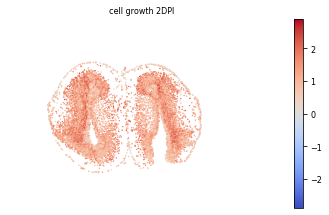

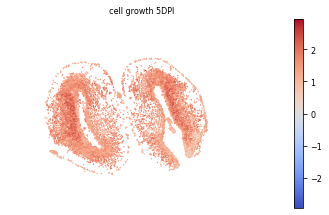

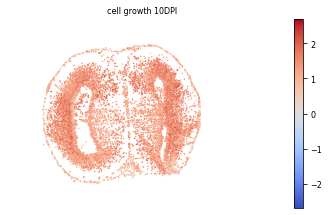

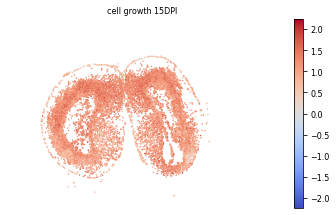

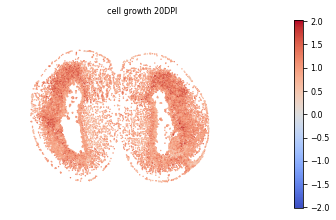

In [103]:
plot_obs_key(adata_0, title='cell growth 2DPI', figsize=(6, (5*2/3)), color_key='cell_growth', cmap='coolwarm',pointsize=2,save_path='/home/lenovo/jora/data/2dpi.pdf')
plot_obs_key(adata_1, title='cell growth 5DPI', figsize=(6, (5*2/3)), color_key='cell_growth', cmap='coolwarm',pointsize=2,save_path='/home/lenovo/jora/data/5dpi.pdf')
#plot_obs_key(adata_1, title='cell growth St54', figsize=(6, (5*2/3)), color_key='cell_growth', cmap='coolwarm',pointsize=2,save_path='/media/lenovo/A06B2FA1620B6FCB/pythonProject/results/tmp/embry2/mouse/St54.pdf')
plot_obs_key(adata_2, title='cell growth 10DPI', figsize=(6, (5*2/3)), color_key='cell_growth', cmap='coolwarm',pointsize=2,save_path='/home/lenovo/jora/data/10dpi.pdf')
plot_obs_key(adata_3, title='cell growth 15DPI', figsize=(6, (5*2/3)), color_key='cell_growth', cmap='coolwarm',pointsize=2,save_path='/home/lenovo/jora/data/15dpi.pdf')
plot_obs_key(adata_4, title='cell growth 20DPI', figsize=(6, (5*2/3)), color_key='cell_growth', cmap='coolwarm',pointsize=2,save_path='/home/lenovo/jora/data/20dpi.pdf')
#plot_obs_key(adata_5, title='cell growth Meta', figsize=(6, (5*2/3)), color_key='cell_growth', cmap='RdBu',pointsize=2,save_path='/media/lenovo/A06B2FA1620B6FCB/pythonProject/results/tmp/embry2/mouse/Meta.pdf')

## Plot interpolation result

In [56]:
common_initial_time_point = 2.0

In [57]:
def evolution_forward(init_cell, model, model_anno, init_time, end_time, init_cell_type, delta_t = 0.1):
    def growth(x, delta_t, model, t, cur_cell_id, sigma_d=0.00001):
        cell_number = x.shape[0]
        x_growth = []
        new_cell_id = []
        g = model.hyper_net3(torch.tensor(t, dtype=torch.float32), x)
        for i in range(cell_number):
            g_i = g[i, :]
            temp = np.random.rand()
            if g_i > 0 and temp < (g_i * delta_t):
                x_growth.append(x[i, :])
                new_cell_id.append(cur_cell_id[i])
                
                new_cell = x[i, :] + sigma_d * torch.tensor(np.random.randn(x[i, :].shape[0]))
                # new_cell[0:3] = torch.maximum(new_cell[0:3], torch.tensor(0.0))
                x_growth.append(new_cell)
                new_cell_id.append(cur_cell_id[i])
            elif g_i > 0 and temp > (g_i * delta_t):
                x_growth.append(x[i, :])
                new_cell_id.append(cur_cell_id[i])
            elif g_i < 0 and temp > (-g_i * delta_t):
                x_growth.append(x[i, :])
                new_cell_id.append(cur_cell_id[i])
        cur_cell = torch.vstack(x_growth)
        cur_cell = torch.tensor(cur_cell, dtype=torch.float32)
        return cur_cell, new_cell_id
    
    time_point = np.arange(init_time, end_time, delta_t)
    time_point = np.union1d(time_point, end_time)
    time_point = np.round(time_point, 1)
    time_step = time_point[1:] - time_point[0:-1]
    
    all_time_point = list(time_point)
    all_exp = []
    all_spa = []
    all_cell_type = []
    all_cell_id = []
    
    cur_cell = init_cell
    cur_cell_id = np.arange(cur_cell.shape[0])
    if init_cell_type is None:
        cur_cell_type = get_cell_type(cur_cell, model_anno, time_point[0])
    else:
        cur_cell_type = [init_cell_type]*cur_cell.shape[0]
    
    for i in range(len(time_point)):
        all_exp.append(cur_cell[:, 0:-2].detach().numpy())
        all_spa.append(cur_cell[:, -2:].detach().numpy())
        all_cell_id.append(cur_cell_id)

        if i > 0:
            cur_cell_type = get_cell_type(cur_cell, model_anno, time_point[i])
    
        all_cell_type.append(cur_cell_type)
    
        if i < len(time_step):
            cur_cell, cur_cell_id = growth(cur_cell, time_step[i], model, time_point[i], cur_cell_id)
            cur_cell[:, 0:-2] = cur_cell[:, 0:-2] + time_step[i] * model.hyper_net1(
                torch.tensor(time_point[i], dtype=torch.float32), cur_cell)
            cur_cell[:, -2:] = cur_cell[:, -2:] + time_step[i] * model.hyper_net2(
                torch.tensor(time_point[i], dtype=torch.float32), cur_cell)
    return all_exp, all_spa, all_cell_type, all_cell_id, all_time_point

In [58]:
#spatial_model.coord_scalers

In [59]:
from cnf_OT2 import disperse_points
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
import os
import torch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
# 将所有模型移到目标设备
model = model.to(device)
spatial_model = model.to(device)
growth_model = growth_model.to(device)

def evolution_forward(init_cell, model, spatial_model, growth_model, init_time, end_time, 
                      init_cell_type=None, delta_t=0.2, trained_scaler=None, max_cells=20000,
                      cnf_generator=None):
    """
    新增参数：
    shape_generator: 加载好的 ImprovedShapeGenerator 实例，用于空间坐标演化
    """
    # 校验：确保传入 shape_generator
    if cnf_generator is None:
        raise ValueError("必须传入加载好的 cnf_generator（ImprovedShapeGenerator 实例）")
    
    def growth(x, delta_t, growth_model, t, cur_cell_id, sigma_d=0.00001):
        # 1. 分离基因表达（前N-2列）和坐标（最后2列），并统一设备
        device = x.device  # 跟随输入x的设备（避免CPU/GPU不匹配）
        x_np = x.detach().cpu().numpy()
        y_np = x_np[:, 0:-2]  # 基因表达部分
        coords_np = x_np[:, -2:]  # 坐标部分
        
        # 2. 用训练好的scaler标准化基因表达（关键修改：不再实时拟合）
        y_transformed = torch.tensor(y_np, dtype=torch.float32, device=device)
        coords = torch.tensor(coords_np, dtype=torch.float32, device=device)
        
        cell_number = x.shape[0]
        x_growth = []
        y_growth=[]
        new_cell_id = []
        
        # 3. 时间张量处理（修复原代码view(-1,1)可能的维度错误，确保输入时间为标量t）
        if not isinstance(t, (int, float)):
            t = t.item()  # 若t是张量，转为标量
        t_tensor = torch.tensor(t, dtype=torch.float32, device=device).view(1, 1)
        t_tensor = t_tensor.repeat(cell_number, 1)  # 形状：(cell_number, 1)
        
        # 4. 生长率预测与约束（限制生长率上限，避免分裂概率>1）
        combined_input = torch.cat([y_transformed, t_tensor], axis=1)
        g = growth_model(combined_input)
        for i in range(cell_number):
            g_i = g[i, :] # 转为标量，避免维度问题
            temp = np.random.rand()
           
            if g_i>1.8 and temp < (g_i * delta_t):
                # 分裂：保留母细胞+新增子细胞（子细胞ID加后缀区分）
                x_growth.append(y_transformed[i,:])
                count=len(x_growth)
                y_growth.append(coords[i,:])
                new_cell_id.append(cur_cell_id[i])  # 母细胞ID
                
                # 子细胞：基因和坐标加小噪声（控制变异程度）
                new_gene = y_transformed[i,:] + sigma_d * torch.randn_like(y_transformed[i,:])
                new_coords= coords[i,:] + sigma_d * torch.randn_like(coords[i,:])
                angle = np.random.uniform(0, 2 * np.pi)
                distance = np.random.exponential(1) + 0.1
                offset_np = np.array([np.cos(angle), np.sin(angle)]) * distance
                offset = torch.tensor(offset_np, dtype=torch.float32, device=device)
                new_coord = new_coords + offset
                x_growth.append(new_gene)
                y_growth.append(new_coord)
                new_cell_id.append(f"{cur_cell_id[i]}_child")  # 子细胞ID加后缀，避免重复
            
            elif g_i>1.8 and temp > (g_i * delta_t):
                x_growth.append(y_transformed[i,:])
                y_growth.append(coords[i,:])
                new_cell_id.append(cur_cell_id[i])
            
            elif g_i<1.8 and temp > (-g_i * delta_t):
                # 存活：仅保留母细胞
                x_growth.append(y_transformed[i,:])
                y_growth.append(coords[i,:])
                new_cell_id.append(cur_cell_id[i])
        
        # 6. 细胞数量上限控制（模拟环境承载）
        if len(x_growth) > max_cells:
            keep_idx = np.random.choice(len(x_growth), max_cells, replace=False)
            x_growth = [x_growth[idx] for idx in keep_idx]
            y_growth = [y_growth[idx] for idx in keep_idx]  # 修复：原代码漏了y_growth的筛选
            new_cell_id = [new_cell_id[idx] for idx in keep_idx]
        
        # 7. 处理无细胞存活的极端情况（避免后续报错）
        if not x_growth:
            return x, cur_cell_id
        
        cur_gene = torch.vstack(x_growth).type(torch.float32)
        cur_coord = torch.vstack(y_growth).type(torch.float32)
        cur_cell = torch.cat([cur_gene, cur_coord], dim=1)
        
        # 8. 更新当前细胞状态
        return cur_cell, new_cell_id
    
    # ---------------------- 主流程 ----------------------
    # 1. 生成连续时间点（与 integrate_backwards 格式一致，正向递推按时间递增）
    int_tps = np.linspace(init_time, end_time, int((end_time - init_time)/delta_t) + 1)  # 如0.0,0.1,...,2.0
    int_tps = np.round(int_tps, 1)  # 避免浮点数误差
    ntimes = len(int_tps)
    print(f"正向递推时间点：{int_tps}（共{ntimes}个）")
    
    # 2. 初始化存储列表（恢复原存储逻辑，不保存基因轨迹）
    all_exp = []
    all_spa = []
    all_cell_type = []
    all_cell_id = []
    
    cur_cell = init_cell
    # 确保初始细胞在正确设备上（与模型一致）
    device = next(growth_model.parameters()).device
    cur_cell = cur_cell.to(device, dtype=torch.float32)
    print(f"初始细胞形状: {cur_cell.shape}, 设备: {device}")
    
    # 3. 初始化细胞ID和初始丰度矩阵
    cur_cell_id = [f"cell_{i}" for i in range(cur_cell.shape[0])]
    if init_cell_type is None:
        cur_cell_type = get_cell_type(cur_cell,  int_tps[0])
    else:
        cur_cell_type = [init_cell_type] * cur_cell.shape[0]
        
    
    # 4. 时间步迭代预测（正向递推，按 int_tps 顺序）
    for i in range(ntimes):
        # 存储当前时间点结果
        all_exp.append(cur_cell[:, 0:-2].detach().cpu().numpy())
        all_spa.append(cur_cell[:, -2:].detach().cpu().numpy())
        all_cell_id.append(cur_cell_id)
        all_cell_type.append(cur_cell_type)
        
        # 若到达最后一个时间点，停止迭代
        if i >= ntimes - 1:
            break
        
        # 5. 生长模型处理
        current_time = int_tps[i]
        next_time = int_tps[i+1]
        time_step = next_time - current_time
        
        cur_cell, cur_cell_id = growth(
            x=cur_cell,
            delta_t=time_step,
            growth_model=growth_model,
            t=current_time,
            cur_cell_id=cur_cell_id,
            sigma_d=0.00001
        )
        
        print(f"细胞形状: {cur_cell.shape}, 设备: {device}")
        # ---------------------- 核心：基因表达模型更新（对齐 integrate_backwards 格式） ----------------------
        z_gene = cur_cell[:, 0:-2]  # 当前基因表达 (n_cells, gene_dim)
        cnf = model.chain[0]  # 与 integrate_backwards 一致，取 chain[0]
        zero = torch.zeros(z_gene.shape[0], 1, device=device)  # 零向量（格式对齐）
        
        # 积分时间：正向递推（从 current_time 到 next_time）
        integration_times = torch.tensor([current_time, next_time], dtype=z_gene.dtype, device=device)
        time_diff = next_time - current_time
        # CNF 正向递推（reverse=False），调用格式与 integrate_backwards 完全对齐
        gene_output, _ = cnf(z_gene, zero, integration_times=integration_times, reverse=False)
        cur_cell[:, 0:-2] = cur_cell[:, 0:-2] + 0.2 * gene_output
        #cur_cell[:, 0:-2]=gene_output 
        # 限制基因表达更新范围（避免数值爆炸）
        # cur_cell[:, 0:-2] = gene_output
        
        # ---------------------- 关键修改：使用 shape_generator 更新空间坐标 ----------------------
        z_spatial = cur_cell[:, -2:].detach().cpu().numpy()  # 当前空间坐标（原始尺度）
        n_cells_current = z_spatial.shape[0]
        
        # 步骤1：使用 shape_generator 的坐标处理器转换为相对坐标
        # 注意：shape_generator 的 train_times 中需包含 current_time 或支持插值
        z_spatial_relative = cnf_generator.coord_processor.transform(z_spatial, current_time)
        
        # 步骤2：转换为张量，传入位移网络预测位移
        z_spatial_tensor = torch.tensor(z_spatial_relative, dtype=z_gene.dtype, device=device)
        time_diff = next_time - current_time  # 当前时间步的时间差
        
        # 步骤3：调用位移网络预测位移（使用 shape_generator 的 displacement_net）
        with torch.no_grad():
            predicted_relative = cnf_generator.cnf(z_spatial_tensor, torch.tensor([0,time_diff]))  # (n_cells, 2)
        
        # 步骤4：计算预测的相对坐标（起始相对坐标 + 位移）
        #predicted_relative = z_spatial_tensor + displacement
        predicted_relative_np = predicted_relative.cpu().numpy()
        
        # 步骤5：分散过近的点（使用用户定义的 _disperse_points）
        predicted_relative_dispersed = disperse_points(predicted_relative_np, min_dist=0.01, max_iter=100)
        
        # 步骤6：反变换回原始坐标尺度
        predicted_coords = cnf_generator.coord_processor.inverse_transform(predicted_relative_dispersed, next_time)
        
        
        
        # 步骤7：更新当前细胞的空间坐标
        cur_cell[:, -2:] = torch.tensor(predicted_coords, dtype=cur_cell.dtype, device=device)
        
        # 6. 预测当前时间点的丰度矩阵
        cur_cell_type = get_cell_type(cur_cell, next_time)

    # 恢复原返回格式
    return all_exp, all_spa, all_cell_type, all_cell_id, int_tps

In [60]:
from sklearn.preprocessing import StandardScaler
emb=adata.obsm['X_ae']
scaler = StandardScaler()
scaler.fit(emb)
transformed = scaler.transform(emb)
adata.obsm['X_trans'] = transformed

KeyError: 'X_ae'

In [ ]:
adata

AnnData object with n_obs × n_vars = 36198 × 34
    obs: 'CellID', 'Batch', 'cell_id', 'Annotation', 'Time', 'time', 'cell_growth', 'time_batch'
    var: 'feature_type', 'var_names_new'
    uns: 'Annotation_colors', 'Batch1_Adult_telencephalon_rep2_DP8400015234BLA3_1', 'Injury_control_FP200000239BL_E3', 'Meta_telencephalon_rep1_DP8400015234BLB2_1', 'Stage44_telencephalon_rep2_FP200000239BL_E4', 'Stage54_telencephalon_rep2_DP8400015649BRD6_2', 'Stage57_telencephalon_rep2_DP8400015649BRD5_1', 'Time_colors', 'angle_dict', 'gae_info', 'original_raw_info', 'time_colors', 'translation_vectors', 'time_batch_colors'
    obsm: 'X_latent', 'coords_normalized', 'original_X', 'original_counts', 'spatial', 'spatial_aligned', 'spatial_original', 'X_ae', 'X_spatial_aligned', 'X_trans'

In [63]:
def load_data_from_anndata(adata, time_key='time', spatial_key='spatial_aligned'):
   
    
    train_time = adata.obs[time_key].unique()
    
    train_time = np.sort(train_time)
    
    # 构建 data_train 字典
    data_train = {}
    for t in train_time:
        # 选择特定时间点的细胞
        adata_t = adata[adata.obs[time_key] == t]
        
        # 获取基因表达数据
        
        gene_expr = adata_t.obsm['X_pca']
        
        # 获取空间坐标
        
        spatial_coords = adata_t.obsm[spatial_key]
            # 如果空间坐标维度大于2，取前两维
          
        # 合并数据
        cell_data = np.concatenate([gene_expr, spatial_coords], axis=1)
        
        # 转换为 PyTorch 张量
        data_train[t] = torch.tensor(cell_data, dtype=torch.float32)
    
    return data_train,train_time

# 使用函数加载数据
data_train,train_time = load_data_from_anndata(adata)
init_cell_5DPI = data_train[train_time[1]]

In [64]:
cnf_model_path = "/home/lenovo/jora/data/shape_generator_ode.pth" 

In [ ]:
class SinusoidalTimeEmbeddings(nn.Module):
    """
    正弦时间位置编码，帮助模型理解时间的连续性和距离
    """
    def __init__(self, time_dim):
        super().__init__()
        self.time_dim = time_dim

    def forward(self, time):
        # time shape: [batch_size, 1]
        device = time.device
        half_dim = self.time_dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

In [65]:
model_anno_path2="/home/lenovo/jora/data/R_model_anno.pth"

In [66]:
from cnf_OT2 import MorphogenesisGenerator
device = 'cuda' if torch.cuda.is_available() else 'cpu'
time_series_data = [adata[adata.obs['time'] == tp] for tp in [0,1,2,3,4] if len(adata[adata.obs['time'] == tp])>0]
cnf_generator = MorphogenesisGenerator.load(
        load_path=cnf_model_path,
        growth_model=growth_model,
        expr_model=model,
        model_anno_path=model_anno_path2,
        time_series_data=time_series_data,
        cell_type_unique=cell_type_unique,
        device=device
    )
cnf_generator.cnf.eval()


Preprocessing spatial data...
Computing OT pairs...
模型已加载: /home/lenovo/jora/data/shape_generator_ode.pth
训练时间点: [0.0, 1.0, 2.0, 3.0, 4.0]


ContinuousTimeCNF(
  (odefunc): ContinuousTimeODEfunc(
    (diffeq): SpatialODENet(
      (net): Sequential(
        (0): Linear(in_features=3, out_features=256, bias=True)
        (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (2): Tanh()
        (3): Linear(in_features=256, out_features=256, bias=True)
        (4): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (5): Tanh()
        (6): Linear(in_features=256, out_features=256, bias=True)
        (7): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (8): Tanh()
        (9): Linear(in_features=256, out_features=2, bias=True)
      )
    )
  )
)

In [ ]:
gene=init_cell_2DPI[:,-2:]

In [ ]:
adata

AnnData object with n_obs × n_vars = 46202 × 16379
    obs: 'CellID', 'spatial_leiden_e30_s8', 'Batch', 'cell_id', 'seurat_clusters', 'inj_uninj', 'D_V', 'Annotation', 'time', 'Time', 'cell_growth', 'time_batch'
    var: 'Gene', 'var_names_new'
    uns: 'Annotation_colors', 'Injury_10DPI_rep1_SS200000147BL_B5', 'Injury_15DPI_rep4_FP200000266TR_E4', 'Injury_20DPI_rep2_SS200000147BL_B4', 'Injury_2DPI_rep1_SS200000147BL_D5', 'Injury_30DPI_rep2_FP200000264BL_A6', 'Injury_5DPI_rep1_SS200000147BL_D2', 'Injury_60DPI_rep3_FP200000264BL_A6', 'Injury_control_FP200000239BL_E3', 'angle_dict', 'transformation_parameters', 'time_batch_colors'
    obsm: 'X_latent', 'X_pca', 'X_spatial', 'X_spatial_aligned', 'spatial', 'spatial_aligned'
    layers: 'counts'

In [162]:
import os
import pandas as pd
import numpy as np
import anndata as ad
import torch

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# from 2DPI to 3.5DPI
init_cell_2DPI = data_train[train_time[0]]

model.eval()
#spatial_model.eval()
growth_model.eval()
#model_anno.eval()

common_initial_time_point = 0
init_time = 0 - common_initial_time_point
end_time = 0.5- common_initial_time_point

# 1. 执行预测
all_exp, all_spa, all_cell_type, all_cell_id, _ = evolution_forward(init_cell_2DPI, model,spatial_model,growth_model, init_time, end_time, delta_t=0.5,cnf_generator=cnf_generator)

# 2. 获取最后时刻的表达矩阵 (处理 Tensor 转 Numpy 的情况，以防万一)
pred_expression = all_exp[-1]
if isinstance(pred_expression, torch.Tensor):
    pred_expression = pred_expression.cpu().detach().numpy()

# 3. 创建 AnnData 对象，将预测的表达量赋值给 X
# 修改处：不再使用 np.zeros，而是直接使用 pred_expression
adata_St54 = ad.AnnData(X=pred_expression)

# 4. 赋值基因名称 (非常重要：没有基因名就无法知道每列代表什么基因)
# 假设原始的 adata 变量中包含了正确的基因列表
if 'adata' in locals() and adata.n_vars == adata_St54.n_vars:
    adata_St54.var_names = adata.var_names

# 5. 赋值空间坐标
adata_St54.obsm['X_spatial_aligned'] = all_spa[-1]

# 6. 赋值细胞类型注释
categories = adata.obs['Annotation'].cat.categories
adata_St54.obs['Annotation'] = pd.Series(
    pd.Categorical(all_cell_type[-1], categories=categories), 
    index=adata_St54.obs.index
)
adata_St54.uns['Annotation_colors'] = adata.uns['Annotation_colors']
adata_St54.write_h5ad('/home/lenovo/jora/data/results_final_struct/pred_2_5dpi.h5ad')
# 7. 绘图
#plot_after_alignment_scanpy(adata_St54, figsize=(6, (5*2/3)), pointsize=8, title='Pred_15_20dpi', show_legend=True,save_path='/home/lenovo/jora/data/pred15_20dpi.pdf')

正向递推时间点：[0.  0.5]（共2个）
初始细胞形状: torch.Size([7668, 32]), 设备: cuda:0
细胞形状: torch.Size([8504, 32]), 设备: cuda:0


绘图完成！文件已保存至: /home/lenovo/jora/data/cell_type_comparison_20dpi.pdf


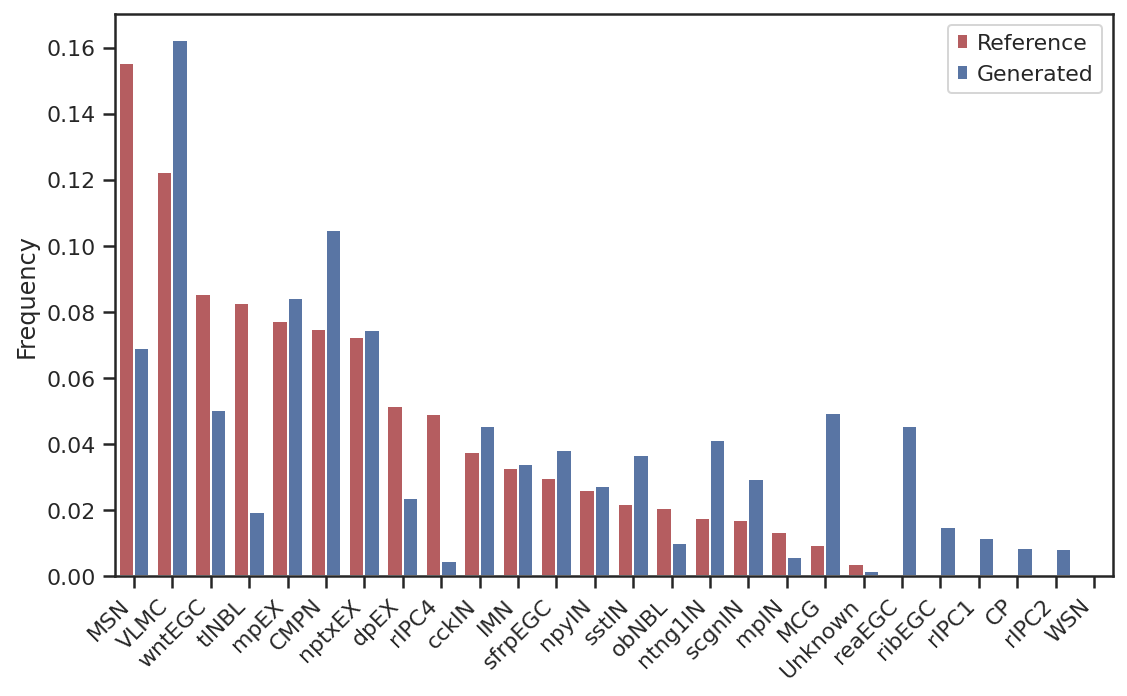

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==========================================
# 1. 定义绘图函数 (不需要修改)
# ==========================================
def plot_cell_type_proportions(true_labels, pred_labels, save_path='comparison.pdf'):
    """
    对比两个列表/数组的细胞类型占比并画图保存
    """
    # 转换为字符串并转为 Series，防止 category 类型导致的索引对齐问题
    s_true = pd.Series(true_labels, name='Cell Type').astype(str)
    s_pred = pd.Series(pred_labels, name='Cell Type').astype(str)
    
    # 计算占比 (Frequency)
    df_true = s_true.value_counts(normalize=True).reset_index()
    df_true.columns = ['Cell Type', 'Frequency']
    df_true['Group'] = 'Reference' # 真实数据（红色）
    
    df_pred = s_pred.value_counts(normalize=True).reset_index()
    df_pred.columns = ['Cell Type', 'Frequency']
    df_pred['Group'] = 'Generated' # 预测数据（蓝色）
    
    # 合并数据
    plot_data = pd.concat([df_true, df_pred], axis=0)
    
    # --- 开始绘图 ---
    sns.set_theme(style="ticks") # 设置简洁风格
    plt.figure(figsize=(8, 5))   # 设置图片大小 (宽, 高)
    
    # 指定颜色：红 vs 蓝
    custom_palette = {'Reference': '#c44e52', 'Generated': '#4c72b0'}
    
    ax = sns.barplot(
        data=plot_data,
        x='Cell Type',
        y='Frequency',
        hue='Group',
        palette=custom_palette,
        edgecolor=None
    )
    
    # 细节调整
    plt.xticks(rotation=45, ha='right') # X轴标签旋转45度
    plt.ylabel('Frequency', fontsize=12)
    plt.xlabel('') # 隐藏X轴标题
    plt.legend(title=None, loc='upper right', frameon=True) # 图例设置
    plt.tight_layout() # 自动调整布局防遮挡
    
    # 保存
    plt.savefig(save_path, format='pdf', dpi=300, bbox_inches='tight')
    print(f"绘图完成！文件已保存至: {save_path}")
    plt.show()

# ==========================================
# 2. 提取数据并画图 (需要修改这里)
# ==========================================

# --- 提取真实数据 ---
# 这里的 adata_2 是你的真实数据变量名
# .values 将其转换为 numpy 数组，去掉索引，这步很重要！
real_data = adata_4.obs['Annotation'].values

# --- 提取预测数据 ---
# 【请注意】这里把 adata_pred 换成你预测数据的变量名
# 如果预测结果在 'predict_label' 列，就改成 .obs['predict_label']
# 假设你的预测数据变量名就是 adata_pred

    # 假设预测数据变量名叫 adata_pred (如果是别的名字，请修改下面这行)
pred_data = adata_St54.obs['Annotation'].values 
    
    # 调用函数画图
plot_cell_type_proportions(
        true_labels=real_data, 
        pred_labels=pred_data, 
        save_path='/home/lenovo/jora/data/cell_type_comparison_20dpi.pdf'
    )


In [151]:
adata_St54.write_h5ad('/home/lenovo/jora/data/results_final_struct/pred_15_20dpi.h5ad')

In [ ]:
pred_adata=sc.read_h5ad('/media/lenovo/A06B2FA1620B6FCB/pythonProject/results_final_struct/predicted_t4.0.h5ad')

In [ ]:
pred_adata

AnnData object with n_obs × n_vars = 14032 × 32
    obs: 'Annotation'
    obsm: 'X_latent', 'spatial'

In [ ]:
categories = adata.obs['Annotation'].cat.categories

pred_adata.uns['Annotation_colors'] = adata.uns['Annotation_colors']
pred_adata.obsm['X_spatial_aligned'] = pred_adata.obsm['spatial']

In [ ]:
plot_after_alignment_scanpy(pred_adata, figsize=(6, (5*2/3)), pointsize=8, title='StMeta', show_legend=True,save_path='/media/lenovo/A06B2FA1620B6FCB/pythonProject/results_final_struct/predMeta5.pdf')

图表已保存为: /media/lenovo/A06B2FA1620B6FCB/pythonProject/results_final_struct/predMeta5.pdf


In [ ]:
adata1.obsm['spatial'][80:120, :]


In [ ]:
adata_0.obs['cell_id']

In [ ]:
all_cell_id[-1]

In [ ]:
import inspect
print(inspect.signature(model.forward))

(x, logpx=None, integration_times=None, reverse=False, inds=None)


In [ ]:
# from 5DPI to 7.5DPI
model.eval()
#spatial_model.eval()
growth_model.eval()
common_initial_time_point=0
init_cell_5DPI = data_train[train_time[2]]
init_time = 2 - common_initial_time_point
end_time =3 - common_initial_time_point
_, all_spa, all_cell_type, _, _ = evolution_forward(init_cell_5DPI, model,spatial_model,growth_model, init_time, end_time, delta_t = 0.2)

adata_St55dot5 = ad.AnnData(np.zeros((len(all_cell_type[-1]),2)))
adata_St55dot5.obsm['X_spatial_aligned'] = all_spa[-1]
categories = adata.obs['Annotation'].cat.categories
adata_St55dot5.obs['Annotation'] = pd.Series(pd.Categorical(all_cell_type[-1], categories=categories), index=adata_St55dot5.obs.index)
adata_St55dot5.uns['Annotation_colors'] = adata.uns['Annotation_colors']

plot_after_alignment_scanpy(adata_St55dot5, figsize=(6, (5*2/3)), pointsize=8, title='Stage Juv.', show_legend=True,save_path='/media/lenovo/A06B2FA1620B6FCB/pythonProject/results/tmp/embry2/mouse/Juv.pdf')

In [ ]:
adata_St55dot5

AnnData object with n_obs × n_vars = 13993 × 2
    obs: 'Annotation'
    uns: 'Annotation_colors'
    obsm: 'X_spatial_aligned'

In [ ]:
# from 10DPI to 12.5DPI
common_initial_time_point=3
init_cell_10DPI = data_train[train_time[3]]
init_time = 3 - common_initial_time_point
end_time = 4 - common_initial_time_point
_, all_spa, all_cell_type, _, _ = evolution_forward(init_cell_10DPI, model,spatial_model,growth_model, init_time, end_time, delta_t = 0.2)

adata_12dot5DPI = ad.AnnData(np.zeros((len(all_cell_type[-1]),2)))
adata_12dot5DPI.obsm['X_spatial_aligned'] = all_spa[-1]
categories = adata.obs['Annotation'].cat.categories
adata_12dot5DPI.obs['Annotation'] = pd.Series(pd.Categorical(all_cell_type[-1], categories=categories), index=adata_12dot5DPI.obs.index)
adata_12dot5DPI.uns['Annotation_colors'] = adata.uns['Annotation_colors']

plot_after_alignment_scanpy(adata_12dot5DPI, figsize=(6, (5*2/3)), pointsize=8, title='Juv', show_legend=True,save_path='/media/lenovo/A06B2FA1620B6FCB/pythonProject/results/tmp/embry2/mouse/12dot5DPI.pdf')


In [ ]:
adata_12dot5DPI

AnnData object with n_obs × n_vars = 132256 × 2
    obs: 'Annotation'
    uns: 'Annotation_colors'
    obsm: 'X_spatial_aligned'

In [ ]:
init_cell_10DPI[:,-2:]

tensor([[1946.2991, 2510.9207],
        [2026.6041, 2525.4841],
        [1984.7279, 2522.1111],
        ...,
        [ 283.5543, 4617.2847],
        [ 103.6161, 4611.1021],
        [ 254.2615, 4621.6357]])

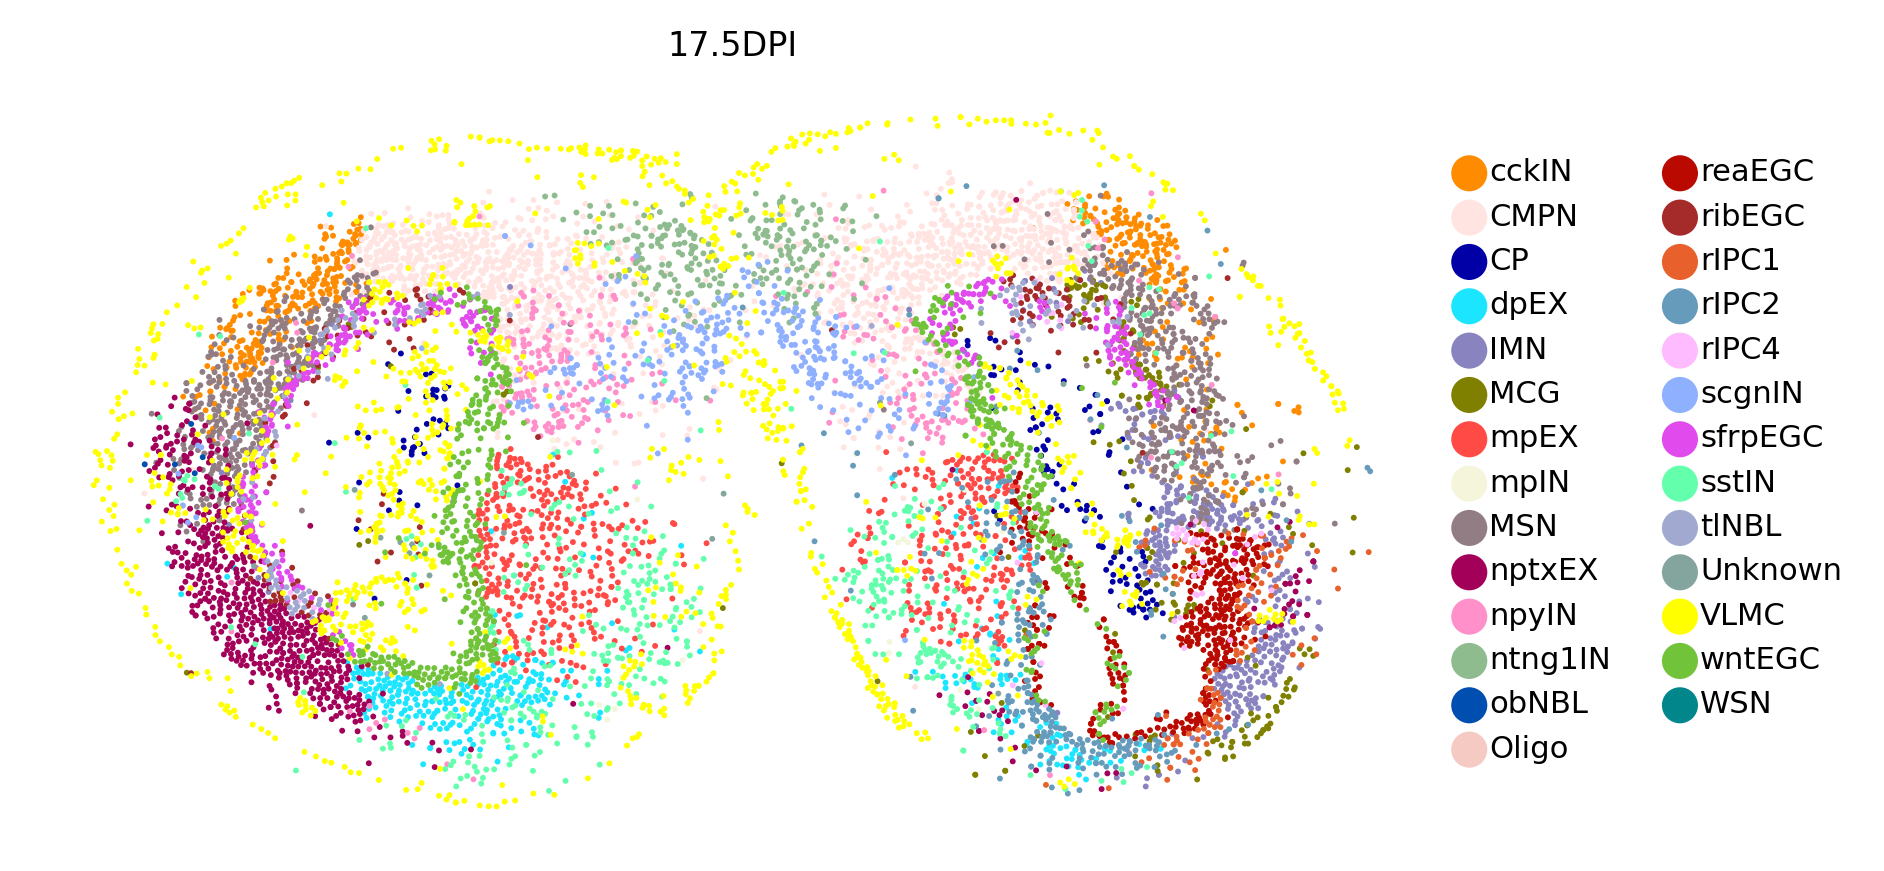

In [ ]:
# from 15DPI to 17.5DPI
init_cell_15DPI = data_train[train_time[3]]
init_time = 15 - common_initial_time_point
end_time = 17.5 - common_initial_time_point
_, all_spa, all_cell_type, _, _ = evolution_forward(init_cell_15DPI, model, model_anno, init_time, end_time, delta_t = 0.1)

adata_17dot5DPI = ad.AnnData(np.zeros((len(all_cell_type[-1]),2)))
adata_17dot5DPI.obsm['X_spatial_after_stVCR'] = all_spa[-1]
categories = adata.obs['Annotation'].cat.categories
adata_17dot5DPI.obs['Annotation'] = pd.Series(pd.Categorical(all_cell_type[-1], categories=categories), index=adata_17dot5DPI.obs.index)
adata_17dot5DPI.uns['Annotation_colors'] = adata.uns['Annotation_colors']

plot_after_alignment_scanpy(adata_17dot5DPI, figsize=(6, (5*2/3)), pointsize=8, title='17.5DPI', show_legend=True)

## Construct time series developmental lineages

In [ ]:
class CellNode:
    def __init__(self, cell_type):
        self.cell_type = cell_type
        self.children = {}
        self.count = 0

def build_transition_tree(all_cell_id, all_cell_type, all_time_point, time_points,eps=1e-6):
    positions=[]
    for cur_time in time_points:
        found_idx = None
        # 遍历all_time_point，找与cur_time误差小于eps的索引
        for idx, t in enumerate(all_time_point):
            if abs(t - cur_time) < eps:
                found_idx = idx
                break  # 找到第一个匹配的即可
        if found_idx is None:
            # 找不到时，提示最接近的值
            closest_t = min(all_time_point, key=lambda x: abs(x - cur_time))
            raise ValueError(
                f"时间点 {cur_time}（误差范围内）不在 all_time_point 中，"
                f"最接近的值是 {closest_t}（误差 {abs(closest_t - cur_time)}）"
            )
        positions.append(found_idx)  # 保存找到的索引
    time_points_data = [(all_cell_type[index], all_cell_id[index]) for index in positions]
    
    if not time_points_data:
        return None
    
    # Initialize the root node with the first time point's unique cell type
    root_type = time_points_data[0][0][0]
    root = CellNode(root_type)
    root.count = len(time_points_data[0][1])
    
    # Dictionary to keep track of current nodes by their ID
    current_nodes = {i: root for i in time_points_data[0][1]}
    
    # Process each time point starting from the second one
    for types, ids in time_points_data[1:]:
        next_nodes = {}
        for cell_type, cell_id in zip(types, ids):
            if cell_id in current_nodes:
                parent_node = current_nodes[cell_id]
                if cell_type not in parent_node.children:
                    parent_node.children[cell_type] = CellNode(cell_type)
                child_node = parent_node.children[cell_type]
                child_node.count += 1
                next_nodes[cell_id] = child_node
        
        # Update current_nodes for the next iteration
        current_nodes = next_nodes
    
    return root

def print_tree(node, level=0, threshold=20):
    if node.count > threshold:
        print("  " * level + f"{node.cell_type} ({node.count})")
        for child in node.children.values():
            print_tree(child, level + 1, threshold)

def plot_sankey_from_tree(transition_tree, cell_type_color_map, threshold=20, title=None, font_size=7, width = 725, height=400, scale=5, save_path=None):
    def tree_to_sankey(transition_tree, threshold, cell_type_color_map):
        labels = []
        sources = []
        targets = []
        values = []
        node_colors = []
        node_indices = {}
        current_index = 0
    
        def traverse_tree(node, parent_index=None):
            nonlocal current_index
            if node.count > threshold:
                node_label = f"{node.cell_type}<br>({node.count})"
                labels.append(node_label)
                node_colors.append(cell_type_color_map.get(node.cell_type, 'gray'))
                node_indices[node] = current_index
                current_node_index = current_index
                current_index += 1
    
                if parent_index is not None:
                    sources.append(parent_index)
                    targets.append(current_node_index)
                    values.append(node.count)
                
                for child in node.children.values():
                    traverse_tree(child, current_node_index)
        traverse_tree(transition_tree)
        
        return labels, sources, targets, values, node_colors

    def _plot_sankey(labels, sources, targets, values, node_colors, title=None, font_size=7, width = 725, height=400, scale=5, save_path=None):
        import plotly.graph_objects as go
        sankey_data = go.Sankey(
            node=dict(
                pad=15,
                thickness=20,
                line=dict(color="black", width=0.5),
                label=labels,
                color=node_colors
            ),
            link=dict(
                source=sources,
                target=targets,
                value=values
            )
        )
        # create figure
        fig = go.Figure(sankey_data)
        
        # update
        fig.update_layout(title=title, font_size=font_size,  width = width, height=height)
        
        # show
        fig.show()
    
        if save_path:
            fig.write_image(save_path,format='pdf', width = 725, height=400, scale=5)
    
    labels, sources, targets, values, node_colors = tree_to_sankey(transition_tree, threshold, cell_type_color_map)
    _plot_sankey(labels, sources, targets, values, node_colors, title=title, font_size=font_size, width = width, height=height, scale=scale, 
                 save_path=save_path)

In [67]:
class CellNode:
    def __init__(self, cell_type):
        self.cell_type = cell_type
        self.children = {}
        self.count = 0

def build_transition_tree(all_cell_id, all_cell_type, all_time_point, time_points,eps=1e-6):
    positions=[]
    for cur_time in time_points:
        found_idx = None
        # 遍历all_time_point，找与cur_time误差小于eps的索引
        for idx, t in enumerate(all_time_point):
            if abs(t - cur_time) < eps:
                found_idx = idx
                break  # 找到第一个匹配的即可
        if found_idx is None:
            # 找不到时，提示最接近的值
            closest_t = min(all_time_point, key=lambda x: abs(x - cur_time))
            raise ValueError(
                f"时间点 {cur_time}（误差范围内）不在 all_time_point 中，"
                f"最接近的值是 {closest_t}（误差 {abs(closest_t - cur_time)}）"
            )
        positions.append(found_idx)  # 保存找到的索引
    time_points_data = [(all_cell_type[index], all_cell_id[index]) for index in positions]
    
    if not time_points_data:
        return None
    
    # Initialize the root node with the first time point's unique cell type
    root_type = time_points_data[0][0][0]
    root = CellNode(root_type)
    root.count = len(time_points_data[0][1])
    
    # Dictionary to keep track of current nodes by their ID
    current_nodes = {i: root for i in time_points_data[0][1]}
    
    # Process each time point starting from the second one
    for types, ids in time_points_data[1:]:
        next_nodes = {}
        for cell_type, cell_id in zip(types, ids):
            if cell_id in current_nodes:
                parent_node = current_nodes[cell_id]
                if cell_type not in parent_node.children:
                    parent_node.children[cell_type] = CellNode(cell_type)
                child_node = parent_node.children[cell_type]
                child_node.count += 1
                next_nodes[cell_id] = child_node
        
        # Update current_nodes for the next iteration
        current_nodes = next_nodes
    
    return root

def print_tree(node, level=0, threshold=20):
    if node.count > threshold:
        print("  " * level + f"{node.cell_type} ({node.count})")
        for child in node.children.values():
            print_tree(child, level + 1, threshold)

def plot_sankey_from_tree(transition_tree, cell_type_color_map, threshold=20, title=None, font_size=7, width = 725, height=400, scale=5, save_path=None):
    def tree_to_sankey(transition_tree, threshold, cell_type_color_map):
        labels = []
        sources = []
        targets = []
        values = []
        node_colors = []
        node_indices = {}
        current_index = 0
    
        def traverse_tree(node, parent_index=None):
            nonlocal current_index
            if node.count > threshold:
                node_label = f"{node.cell_type}<br>({node.count})"
                labels.append(node_label)
                node_colors.append(cell_type_color_map.get(node.cell_type, 'gray'))
                node_indices[node] = current_index
                current_node_index = current_index
                current_index += 1
    
                if parent_index is not None:
                    sources.append(parent_index)
                    targets.append(current_node_index)
                    values.append(node.count)
                
                for child in node.children.values():
                    traverse_tree(child, current_node_index)
        traverse_tree(transition_tree)
        
        return labels, sources, targets, values, node_colors

    def _plot_sankey(labels, sources, targets, values, node_colors, title=None, font_size=7, width = 725, height=400, scale=5, save_path=None):
        import plotly.graph_objects as go
        sankey_data = go.Sankey(
            node=dict(
                pad=15,
                thickness=20,
                line=dict(color="black", width=0.5),
                label=labels,
                color=node_colors
            ),
            link=dict(
                source=sources,
                target=targets,
                value=values
            )
        )
        # create figure
        fig = go.Figure(sankey_data)
        
        # update
        fig.update_layout(title=title, font_size=font_size,  width = width, height=height)
        
        # show
        fig.show()
    
        if save_path:
            fig.write_image(save_path,format='pdf', width = 725, height=400, scale=5)
    
    labels, sources, targets, values, node_colors = tree_to_sankey(transition_tree, threshold, cell_type_color_map)
    _plot_sankey(labels, sources, targets, values, node_colors, title=title, font_size=font_size, width = width, height=height, scale=scale, 
                 save_path=save_path)

In [68]:
adata_mcg = adata[adata.obs.Annotation == 'MCG', :]

data_train_mcg, _, = load_data_from_anndata(adata_mcg)

In [87]:
adata_tlnbl = adata[adata.obs.Annotation == 'tlNBL', :]

data_train_tlnbl, _, = load_data_from_anndata(adata_tlnbl)

In [69]:
adata_sfrp = adata[adata.obs.Annotation == 'sfrpEGC', :]
data_train_sfrp, _ = load_data_from_anndata(adata_sfrp)

In [92]:
adata_rib = adata[adata.obs.Annotation == 'ribEGC', :]
data_train_rib, _ = load_data_from_anndata(adata_rib)

In [70]:
adata_wnt = adata[adata.obs.Annotation == 'wntEGC', :]
data_train_wnt, _=load_data_from_anndata(adata_wnt)

In [71]:
adata_rea = adata[adata.obs.Annotation == 'reaEGC', :]
data_train_rea, _=load_data_from_anndata(adata_rea)

In [72]:
adata_rIPC1 = adata[adata.obs.Annotation == 'rIPC1', :]
data_train_rIPC1,  _ = load_data_from_anndata(adata_rIPC1)
adata_rIPC2 = adata[adata.obs.Annotation == 'rIPC2', :]
data_train_rIPC2,  _ = load_data_from_anndata(adata_rIPC2)

In [140]:
# wntEGC at 5DPI to 10DPI
common_initial_time_point=0
init_cell_wnt_5DPI =data_train_mcg[train_time[0]]
init_cell_type = 'MCG'
init_time =2 - common_initial_time_point
end_time =3 - common_initial_time_point
_, _, all_cell_type, all_cell_id, all_time_point = evolution_forward(init_cell_wnt_5DPI, model,spatial_model,growth_model, init_time, end_time, init_cell_type,delta_t = 0.5,cnf_generator=cnf_generator)
#init_time = 1 - common_initial_time_point
#end_time = 2 - common_initial_time_point
#_, _, all_cell_type, all_cell_id, all_time_point = evolution_forward(init_cell_wnt_5DPI, model,spatial_model,growth_model, init_time, end_time, delta_t = 0.2)



time_points = [2,  2.5,3.0]
# time_points = [5, 7.5, 10]
time_points = [cur_time - common_initial_time_point for cur_time in time_points]
transition_tree_wnt_5DPI = build_transition_tree(all_cell_id, all_cell_type, all_time_point, time_points)
plot_sankey_from_tree(transition_tree_wnt_5DPI, cell_type_color_map, threshold=15, title='MGC at 10dpi to 15dpi', 
                      font_size=15.3, width = 725, height=500, scale=5, save_path="/home/lenovo/jora/data/results_final_struct/MGC at 10dpi to 15dpi.pdf")


正向递推时间点：[2.  2.5 3. ]（共3个）
初始细胞形状: torch.Size([121, 32]), 设备: cuda:0
细胞形状: torch.Size([121, 32]), 设备: cuda:0
细胞形状: torch.Size([121, 32]), 设备: cuda:0


正向递推时间点：[1.  1.5 2. ]（共3个）
初始细胞形状: torch.Size([314, 32]), 设备: cuda:0
细胞形状: torch.Size([375, 32]), 设备: cuda:0
细胞形状: torch.Size([379, 32]), 设备: cuda:0


图表已保存为: /home/lenovo/jora/data/rib10dpi.pdf


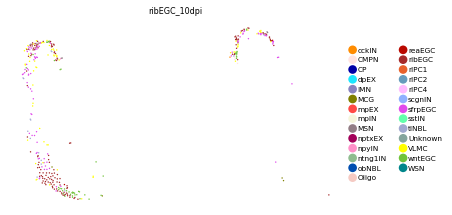

In [145]:
# wntEGC at 5DPI to 10DPI
common_initial_time_point=0
init_cell_wnt_5DPI =data_train_rib[train_time[1]]
init_cell_type = 'ribEGC'
init_time =1 - common_initial_time_point
end_time =2 - common_initial_time_point
_, all_spa, all_cell_type, all_cell_id, all_time_point = evolution_forward(init_cell_wnt_5DPI, model,spatial_model,growth_model, init_time, end_time, init_cell_type,delta_t = 0.5,cnf_generator=cnf_generator)
#init_time = 1 - common_initial_time_point
#end_time = 2 - common_initial_time_point
#_, _, all_cell_type, all_cell_id, all_time_point = evolution_forward(init_cell_wnt_5DPI, model,spatial_model,growth_model, init_time, end_time, delta_t = 0.2)



time_points = [1,  1.5,2.0]
# time_points = [5, 7.5, 10]
time_points = [cur_time - common_initial_time_point for cur_time in time_points]
transition_tree_wnt_5DPI = build_transition_tree(all_cell_id, all_cell_type, all_time_point, time_points)
adata_St55dot5 = ad.AnnData(np.zeros((len(all_cell_type[-1]),2)))
adata_St55dot5.obsm['X_spatial_aligned'] = all_spa[-1]
categories = adata.obs['Annotation'].cat.categories
adata_St55dot5.obs['Annotation'] = pd.Series(pd.Categorical(all_cell_type[-1], categories=categories), index=adata_St55dot5.obs.index)
adata_St55dot5.uns['Annotation_colors'] = adata.uns['Annotation_colors']
plot_sankey_from_tree(transition_tree_wnt_5DPI, cell_type_color_map, threshold=5, title='ribEGC at 5dpi to 10dpi', 
                      font_size=15.3, width = 725, height=500, scale=5, save_path="/home/lenovo/jora/data/results_final_struct/ribEGC at 5dpi to 10dpi.pdf")
plot_after_alignment_scanpy(adata_St55dot5, figsize=(6, (5*2/3)), pointsize=8, title='ribEGC_10dpi', show_legend=True,save_path='/home/lenovo/jora/data/rib10dpi.pdf')


In [148]:
# wntEGC at 5DPI to 10DPI
common_initial_time_point=0
init_cell_wnt_5DPI =data_train_wnt[train_time[1]]
init_cell_type = 'wntEGC'
init_time =1 - common_initial_time_point
end_time =2 - common_initial_time_point
_, all_spa, all_cell_type, all_cell_id, all_time_point = evolution_forward(init_cell_wnt_5DPI, model,spatial_model,growth_model, init_time, end_time, init_cell_type,delta_t = 0.5,cnf_generator=cnf_generator)
#init_time = 1 - common_initial_time_point
#end_time = 2 - common_initial_time_point
#_, _, all_cell_type, all_cell_id, all_time_point = evolution_forward(init_cell_wnt_5DPI, model,spatial_model,growth_model, init_time, end_time, delta_t = 0.2)



time_points = [1,  1.5,2.0]
# time_points = [5, 7.5, 10]
time_points = [cur_time - common_initial_time_point for cur_time in time_points]
transition_tree_wnt_5DPI = build_transition_tree(all_cell_id, all_cell_type, all_time_point, time_points)
adata_St55dot5 = ad.AnnData(np.zeros((len(all_cell_type[-1]),2)))
adata_St55dot5.obsm['X_spatial_aligned'] = all_spa[-1]
categories = adata.obs['Annotation'].cat.categories
adata_St55dot5.obs['Annotation'] = pd.Series(pd.Categorical(all_cell_type[-1], categories=categories), index=adata_St55dot5.obs.index)
adata_St55dot5.uns['Annotation_colors'] = adata.uns['Annotation_colors']
plot_sankey_from_tree(transition_tree_wnt_5DPI, cell_type_color_map, threshold=15, title='wntEGC at 5dpi to 10dpi', 
                      font_size=15.3, width = 725, height=500, scale=5, save_path="/home/lenovo/jora/data/results_final_struct/wntEGC at 2dpi to 5dpi.pdf")
#plot_after_alignment_scanpy(adata_St55dot5, figsize=(6, (5*2/3)), pointsize=8, title='wntEGC_10dpi', show_legend=True,save_path='/home/lenovo/jora/data/wnt10dpi.pdf')


正向递推时间点：[1.  1.5 2. ]（共3个）
初始细胞形状: torch.Size([505, 32]), 设备: cuda:0
细胞形状: torch.Size([536, 32]), 设备: cuda:0
细胞形状: torch.Size([535, 32]), 设备: cuda:0


正向递推时间点：[2.  2.5 3. ]（共3个）
初始细胞形状: torch.Size([121, 32]), 设备: cuda:0
细胞形状: torch.Size([121, 32]), 设备: cuda:0
细胞形状: torch.Size([121, 32]), 设备: cuda:0
图表已保存为: /home/lenovo/jora/data/MCG15dpi.pdf


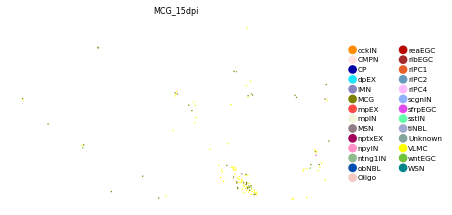

In [135]:
# wntEGC at 5DPI to 10DPI
common_initial_time_point=0
init_cell_wnt_5DPI =data_train_mcg[train_time[0]]
init_cell_type = 'MCG'
init_time =2 - common_initial_time_point
end_time =3 - common_initial_time_point
_, all_spa, all_cell_type, all_cell_id, all_time_point = evolution_forward(init_cell_wnt_5DPI, model,spatial_model,growth_model, init_time, end_time, init_cell_type,delta_t = 0.5,cnf_generator=cnf_generator)
#init_time = 1 - common_initial_time_point
#end_time = 2 - common_initial_time_point
#_, _, all_cell_type, all_cell_id, all_time_point = evolution_forward(init_cell_wnt_5DPI, model,spatial_model,growth_model, init_time, end_time, delta_t = 0.2)



time_points = [2,  2.5,3.0]
# time_points = [5, 7.5, 10]
time_points = [cur_time - common_initial_time_point for cur_time in time_points]
transition_tree_wnt_5DPI = build_transition_tree(all_cell_id, all_cell_type, all_time_point, time_points)
adata_St55dot5 = ad.AnnData(np.zeros((len(all_cell_type[-1]),2)))
adata_St55dot5.obsm['X_spatial_aligned'] = all_spa[-1]
categories = adata.obs['Annotation'].cat.categories
adata_St55dot5.obs['Annotation'] = pd.Series(pd.Categorical(all_cell_type[-1], categories=categories), index=adata_St55dot5.obs.index)
adata_St55dot5.uns['Annotation_colors'] = adata.uns['Annotation_colors']
#plot_sankey_from_tree(transition_tree_wnt_5DPI, cell_type_color_map, threshold=15, title='ribEGC at 5dpi to 10dpi', 
                      #font_size=15.3, width = 725, height=500, scale=5, save_path="/home/lenovo/jora/data/results_final_struct/ribEGC at 2dpi to 5dpi.pdf")
plot_after_alignment_scanpy(adata_St55dot5, figsize=(6, (5*2/3)), pointsize=8, title='MCG_15dpi', show_legend=True,save_path='/home/lenovo/jora/data/MCG15dpi.pdf')


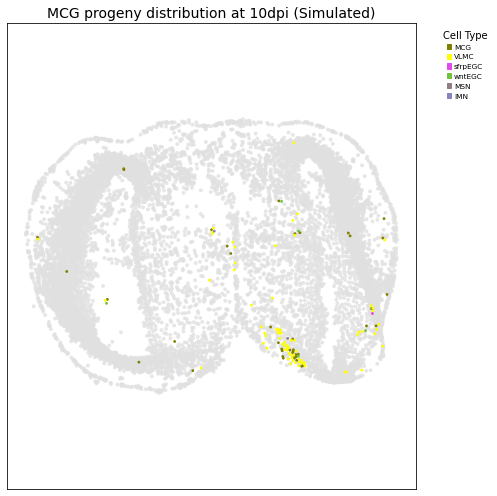

Figure saved to /home/lenovo/jora/data/MCG15dpi_spatial_distribution.pdf


In [136]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# ==========================================
# 1. 准备数据
# ==========================================

# A. 获取背景数据 (10DPI 的真实数据)
# 假设 train_time[2] 是 10DPI。如果不是，请替换成你存放 10DPI 真实数据的变量
# 例如: adata_bg = adata[adata.obs['Timepoint'] == '10DPI']
adata_bg = sc.read_h5ad('/home/lenovo/jora/data/results_final_struct/pred_15dpi.h5ad') 

# B. 获取前景数据 (模拟的预测数据)
adata_fg = adata_St55dot5  # 这是你代码里生成的那个 AnnData

# ==========================================
# 2. 准备颜色映射 (与原始数据保持一致)
# ==========================================
# 我们需要确保 "ribEGC" 在这里显示的颜色和在整篇论文里是一样的
# 从原始的大 adata 中提取颜色字典
if 'Annotation_colors' in adata.uns:
    cat_colors = adata.uns['Annotation_colors']
    categories = adata.obs['Annotation'].cat.categories
    cell_type_color_map = dict(zip(categories, cat_colors))
else:
    # 如果没有预设颜色，生成一个临时的
    import seaborn as sns
    all_cats = list(set(adata_fg.obs['Annotation'].unique()) | set(adata_bg.obs['Annotation'].unique()))
    palette = sns.color_palette("tab20", len(all_cats))
    cell_type_color_map = dict(zip(all_cats, palette))

# ==========================================
# 3. 开始绘图
# ==========================================
fig, ax = plt.subplots(figsize=(7, 7)) # 画布大小

# --- 第一步：绘制灰色背景 (Context) ---
# 提取背景坐标
bg_coords = adata_bg.obsm['X_spatial_aligned'] # 确保这里用的也是 aligned 坐标

ax.scatter(bg_coords[:, 0], 
           bg_coords[:, 1],
           c='#e0e0e0',    # 浅灰色
           s=15,           # 背景点大小，可以稍微大一点填充轮廓
           edgecolors='none', 
           alpha=0.8,      # 透明度
           label='Other cells (Context)')

# --- 第二步：绘制预测的前景细胞 (Predicted) ---
# 我们需要按类别循环绘制，以便分配不同的颜色
fg_categories = adata_fg.obs['Annotation'].unique()
legend_handles = []

for c_type in fg_categories:
    # 找到属于该类型的细胞索引
    idx = adata_fg.obs['Annotation'] == c_type
    fg_coords = adata_fg.obsm['X_spatial_aligned'][idx]
    
    if len(fg_coords) > 0:
        # 获取该类型的标准颜色
        color = cell_type_color_map.get(c_type, 'black')
        
        ax.scatter(fg_coords[:, 0], 
                   fg_coords[:, 1],
                   c=[color],       # 颜色
                   s=8,             # 前景点大小，通常比背景略小或相等以显示精度
                   edgecolors='none',
                   alpha=1.0,       # 前景完全不透明，突出显示
                   label=c_type,
                   zorder=10)       # 确保前景画在背景上面
        
        # 添加图例句柄
        legend_handles.append(mpatches.Patch(color=color, label=c_type))

# ==========================================
# 4. 调整显示与保存
# ==========================================
ax.set_title('MCG progeny distribution at 10dpi (Simulated)', fontsize=14)
ax.axis('equal') # 保持纵横比，避免组织变形
ax.set_xticks([]) # 移除坐标轴刻度，更像空间图
ax.set_yticks([])
# ax.axis('off')  # 或者直接把框线也去掉，只留点

# 添加图例
# bbox_to_anchor 控制图例位置，避免遮挡图形
plt.legend(handles=legend_handles, 
           title='Cell Type', 
           bbox_to_anchor=(1.05, 1), 
           loc='upper left', 
           frameon=False)

plt.tight_layout()

# 保存路径
save_path = '/home/lenovo/jora/data/MCG15dpi_spatial_distribution.pdf'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved to {save_path}")

In [76]:
import kaleido
kaleido.get_chrome_sync()

PosixPath('/home/lenovo/anaconda3/envs/graphode/lib/python3.8/site-packages/choreographer/cli/browser_exe/chrome-linux64/chrome')

In [137]:
# wntEGC at 5DPI to 10DPI
common_initial_time_point=0
init_cell_wnt_5DPI =data_train_wnt[train_time[0]]
init_cell_type = 'wntEGC'
init_time = 1 - common_initial_time_point
end_time = 2 - common_initial_time_point
_, _, all_cell_type, all_cell_id, all_time_point = evolution_forward(init_cell_wnt_5DPI, model,spatial_model,growth_model, init_time, end_time, init_cell_type,delta_t = 0.5,cnf_generator=cnf_generator)
#init_time = 1 - common_initial_time_point
#end_time = 2 - common_initial_time_point
#_, _, all_cell_type, all_cell_id, all_time_point = evolution_forward(init_cell_wnt_5DPI, model,spatial_model,growth_model, init_time, end_time, delta_t = 0.2)



time_points = [1,  1.5, 2.0]
# time_points = [5, 7.5, 10]
time_points = [cur_time - common_initial_time_point for cur_time in time_points]
transition_tree_wnt_5DPI = build_transition_tree(all_cell_id, all_cell_type, all_time_point, time_points)
plot_sankey_from_tree(transition_tree_wnt_5DPI, cell_type_color_map, threshold=10, title='wntEGC at 5dpi to 10dpi', 
                      font_size=15.3, width = 725, height=500, scale=5, save_path="/home/lenovo/jora/data/results_final_struct/wntEGC at 5dpi to 10dpi2.pdf")


正向递推时间点：[1.  1.5 2. ]（共3个）
初始细胞形状: torch.Size([351, 32]), 设备: cuda:0
细胞形状: torch.Size([352, 32]), 设备: cuda:0
细胞形状: torch.Size([352, 32]), 设备: cuda:0


In [167]:
# wntEGC at 5DPI to 10DPI
common_initial_time_point=0
init_cell_wnt_5DPI =data_train_rea[train_time[0]]
init_cell_type = 'reaEGC'
init_time =2 - common_initial_time_point
end_time = 3 - common_initial_time_point
_, _, all_cell_type, all_cell_id, all_time_point = evolution_forward(init_cell_wnt_5DPI, model,spatial_model,growth_model, init_time, end_time, init_cell_type,delta_t = 0.5,cnf_generator=cnf_generator)
#init_time = 1 - common_initial_time_point
#end_time = 2 - common_initial_time_point
#_, _, all_cell_type, all_cell_id, all_time_point = evolution_forward(init_cell_wnt_5DPI, model,spatial_model,growth_model, init_time, end_time, delta_t = 0.2)



time_points = [2,  2.5, 3.0]
# time_points = [5, 7.5, 10]
time_points = [cur_time - common_initial_time_point for cur_time in time_points]
transition_tree_wnt_5DPI = build_transition_tree(all_cell_id, all_cell_type, all_time_point, time_points)
plot_sankey_from_tree(transition_tree_wnt_5DPI, cell_type_color_map, threshold=5, title='reaEGC at 10dpi to 15dpi', 
                      font_size=15.3, width = 725, height=500, scale=5, save_path="/home/lenovo/jora/data/results_final_struct/reaEGC at 10dpi to 15dp2.pdf")


正向递推时间点：[2.  2.5 3. ]（共3个）
初始细胞形状: torch.Size([254, 32]), 设备: cuda:0
细胞形状: torch.Size([254, 32]), 设备: cuda:0
细胞形状: torch.Size([254, 32]), 设备: cuda:0


In [139]:
# wntEGC at 5DPI to 10DPI
common_initial_time_point=0
init_cell_wnt_5DPI =data_train_sfrp[train_time[0]]
init_cell_type = 'sfrpEGC'
init_time = 1 - common_initial_time_point
end_time = 2 - common_initial_time_point
_, _, all_cell_type, all_cell_id, all_time_point = evolution_forward(init_cell_wnt_5DPI, model,spatial_model,growth_model, init_time, end_time, init_cell_type,delta_t =0.5,cnf_generator=cnf_generator)
#init_time = 1 - common_initial_time_point
#end_time = 2 - common_initial_time_point
#_, _, all_cell_type, all_cell_id, all_time_point = evolution_forward(init_cell_wnt_5DPI, model,spatial_model,growth_model, init_time, end_time, delta_t = 0.2)



time_points = [1,1.5,2]
# time_points = [5, 7.5, 10]
time_points = [cur_time - common_initial_time_point for cur_time in time_points]
transition_tree_wnt_5DPI = build_transition_tree(all_cell_id, all_cell_type, all_time_point, time_points)
plot_sankey_from_tree(transition_tree_wnt_5DPI, cell_type_color_map, threshold=3, title='sfrpEGC 5dpi to 10dpi', 
                      font_size=15.3, width = 725, height=500, scale=5, save_path="/home/lenovo/jora/data/results_final_struct/sfrpEGC at 5dpi to 10dpi2.pdf")


正向递推时间点：[1.  1.5 2. ]（共3个）
初始细胞形状: torch.Size([283, 32]), 设备: cuda:0
细胞形状: torch.Size([283, 32]), 设备: cuda:0
细胞形状: torch.Size([282, 32]), 设备: cuda:0


In [91]:
# wntEGC at 5DPI to 10DPI
common_initial_time_point=0
init_cell_wnt_5DPI =data_train_tlnbl[train_time[1]]
init_cell_type = 'tlNBL'
init_time = 1 - common_initial_time_point
end_time = 2 - common_initial_time_point
_, _, all_cell_type, all_cell_id, all_time_point = evolution_forward(init_cell_wnt_5DPI, model,spatial_model,growth_model, init_time, end_time, init_cell_type,delta_t = 0.5,cnf_generator=cnf_generator)
#init_time = 1 - common_initial_time_point
#end_time = 2 - common_initial_time_point
#_, _, all_cell_type, all_cell_id, all_time_point = evolution_forward(init_cell_wnt_5DPI, model,spatial_model,growth_model, init_time, end_time, delta_t = 0.2)



time_points = [1,  1.5,2.0]
# time_points = [5, 7.5, 10]
time_points = [cur_time - common_initial_time_point for cur_time in time_points]
transition_tree_wnt_5DPI = build_transition_tree(all_cell_id, all_cell_type, all_time_point, time_points)
plot_sankey_from_tree(transition_tree_wnt_5DPI, cell_type_color_map, threshold=15, title='tlNBL at 5dpi to 10dpi', 
                      font_size=15.3, width = 725, height=500, scale=5, save_path="/home/lenovo/jora/data/results_final_struct/tlNBL at 5dpi to 10dpi.pdf")


正向递推时间点：[1.  1.5 2. ]（共3个）
初始细胞形状: torch.Size([289, 32]), 设备: cuda:0
细胞形状: torch.Size([457, 32]), 设备: cuda:0
细胞形状: torch.Size([489, 32]), 设备: cuda:0


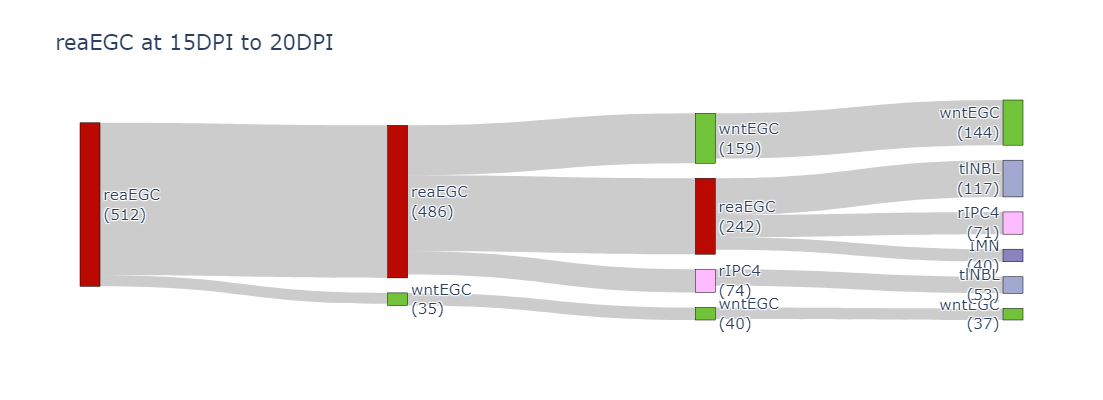

In [ ]:
# reaEGC at 15DPI to 20DPI
init_cell_rea_15DPI = data_train_rea[train_time[3]]
init_cell_type = 'reaEGC'
init_time = 15 - common_initial_time_point
end_time = 20 - common_initial_time_point
_, _, all_cell_type, all_cell_id, all_time_point = evolution_forward(init_cell_rea_15DPI, model, model_anno, init_time, end_time, init_cell_type, 
                                                                     delta_t = 0.1)


time_points = [15, 16.7, 18.4, 20]
time_points = [cur_time - common_initial_time_point for cur_time in time_points]
transition_tree_rea_15DPI = build_transition_tree(all_cell_id, all_cell_type, all_time_point, time_points)
plot_sankey_from_tree(transition_tree_rea_15DPI, cell_type_color_map, threshold=26, title='reaEGC at 15DPI to 20DPI', 
                      font_size=15.3, width = 725, height=400, scale=5, save_path=None)

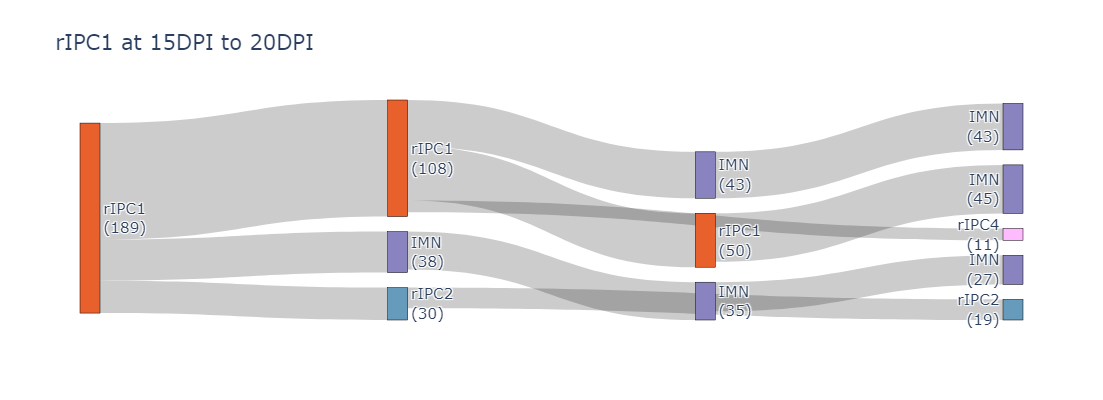

In [ ]:
# rIPC1 at 15DPI to 20DPI
init_cell_rIPC1_15DPI = data_train_rIPC1[train_time[0]]
init_cell_type = 'rIPC1'
init_time = 15 - common_initial_time_point
end_time = 20 - common_initial_time_point
_, _, all_cell_type, all_cell_id, all_time_point = evolution_forward(init_cell_rIPC1_15DPI, model, model_anno, init_time, end_time, init_cell_type, 
                                                                     delta_t = 0.1)


time_points = [15, 16.7, 18.4, 20]
time_points = [cur_time - common_initial_time_point for cur_time in time_points]
transition_tree_rIPC1_15DPI = build_transition_tree(all_cell_id, all_cell_type, all_time_point, time_points)
plot_sankey_from_tree(transition_tree_rIPC1_15DPI, cell_type_color_map, threshold=9, title='rIPC1 at 15DPI to 20DPI', 
                      font_size=15.3, width = 725, height=400, scale=5, save_path=None)

In [ ]:
# wntEGC at 5DPI to 10DPI
common_initial_time_point=0
init_cell_wnt_5DPI =data_train_rIPC1[train_time[3]]
init_cell_type = 'rIPC1'
init_time = 3 - common_initial_time_point
end_time = 4 - common_initial_time_point
_, _, all_cell_type, all_cell_id, all_time_point = evolution_forward(init_cell_wnt_5DPI, model,spatial_model,growth_model, init_time, end_time, init_cell_type,delta_t =0.5,cnf_generator=cnf_generator)
#init_time = 1 - common_initial_time_point
#end_time = 2 - common_initial_time_point
#_, _, all_cell_type, all_cell_id, all_time_point = evolution_forward(init_cell_wnt_5DPI, model,spatial_model,growth_model, init_time, end_time, delta_t = 0.2)



time_points = [3,3.5,4]
# time_points = [5, 7.5, 10]
time_points = [cur_time - common_initial_time_point for cur_time in time_points]
transition_tree_wnt_5DPI = build_transition_tree(all_cell_id, all_cell_type, all_time_point, time_points)
plot_sankey_from_tree(transition_tree_wnt_5DPI, cell_type_color_map, threshold=5, title='rIPC1', 
                      font_size=15.3, width = 725, height=500, scale=5, save_path=None)


正向递推时间点：[3.  3.5 4. ]（共3个）
初始细胞形状: torch.Size([189, 32]), 设备: cuda:0
细胞形状: torch.Size([191, 32]), 设备: cuda:0
细胞形状: torch.Size([193, 32]), 设备: cuda:0


In [ ]:
# wntEGC at 5DPI to 10DPI
common_initial_time_point=0
init_cell_wnt_5DPI =data_train_rIPC2[train_time[3]]
init_cell_type = 'rIPC2'
init_time = 3 - common_initial_time_point
end_time = 4 - common_initial_time_point
_, _, all_cell_type, all_cell_id, all_time_point = evolution_forward(init_cell_wnt_5DPI, model,spatial_model,growth_model, init_time, end_time, init_cell_type,delta_t =0.5,cnf_generator=cnf_generator)
#init_time = 1 - common_initial_time_point
#end_time = 2 - common_initial_time_point
#_, _, all_cell_type, all_cell_id, all_time_point = evolution_forward(init_cell_wnt_5DPI, model,spatial_model,growth_model, init_time, end_time, delta_t = 0.2)



time_points = [3,3.5,4]
# time_points = [5, 7.5, 10]
time_points = [cur_time - common_initial_time_point for cur_time in time_points]
transition_tree_wnt_5DPI = build_transition_tree(all_cell_id, all_cell_type, all_time_point, time_points)
plot_sankey_from_tree(transition_tree_wnt_5DPI, cell_type_color_map, threshold=7, title='rIPC2', 
                      font_size=15.3, width = 725, height=500, scale=5, save_path=None)


正向递推时间点：[3.  3.5 4. ]（共3个）
初始细胞形状: torch.Size([268, 32]), 设备: cuda:0
细胞形状: torch.Size([272, 32]), 设备: cuda:0


细胞形状: torch.Size([272, 32]), 设备: cuda:0


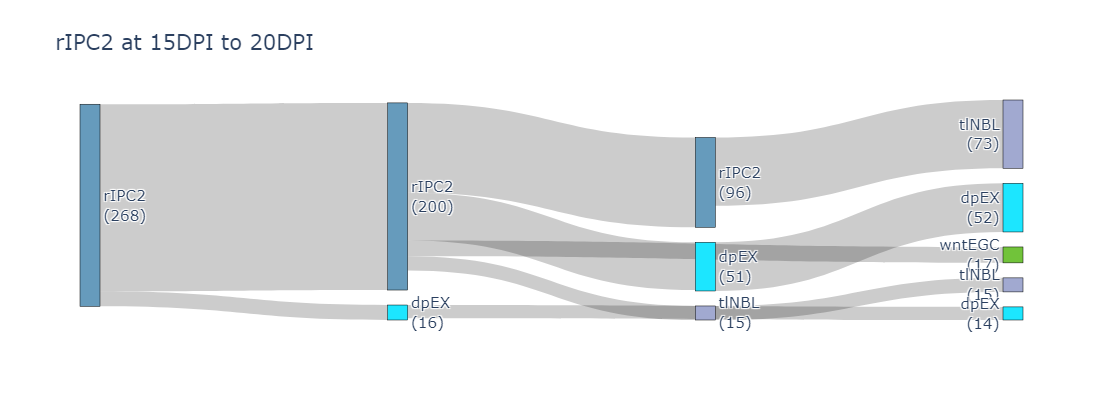

In [ ]:
# rIPC2 at 15DPI to 20DPI
init_cell_rIPC2_15DPI = data_train_rIPC2[train_time[0]]
init_cell_type = 'rIPC2'
init_time = 15 - common_initial_time_point
end_time = 20 - common_initial_time_point
_, _, all_cell_type, all_cell_id, all_time_point = evolution_forward(init_cell_rIPC2_15DPI, model, model_anno, init_time, end_time, init_cell_type, 
                                                                     delta_t = 0.1)


time_points = [15, 16.7, 18.4, 20]
time_points = [cur_time - common_initial_time_point for cur_time in time_points]
transition_tree_rIPC2_15DPI = build_transition_tree(all_cell_id, all_cell_type, all_time_point, time_points)
plot_sankey_from_tree(transition_tree_rIPC2_15DPI, cell_type_color_map, threshold=13, title='rIPC2 at 15DPI to 20DPI', 
                      font_size=15.3,width = 725, height=400, scale=5, save_path=None)

## Plot cell number

In [ ]:
def plot_all_type_number_time(data, all_time, cell_type, cell_type_color_map, figsize = (6, 5.5), marker_idx=None, save_path=None):
    import matplotlib.pyplot as plt
    from collections import Counter
    
    # 计算每团点云的类型的个数
    type_counts_per_cloud = [Counter(cloud) for cloud in data]
    
    # 提取所有可能的类型
    # all_types = set(cur_type for cloud in data for cur_type in cloud)
    all_types = cell_type
    
    # 创建一个字典来存储每种类型在每个时间点的计数
    type_counts_over_time = {cur_type: [] for cur_type in all_types}
    
    # 填充字典
    for counts in type_counts_per_cloud:
        for cur_type in all_types:
            type_counts_over_time[cur_type].append(counts[cur_type])
    
    # 绘制折线图
    plt.figure(figsize=figsize)
    for cur_type, counts in type_counts_over_time.items():
        if marker_idx:
            plt.plot(np.array(all_time) + 2.0, counts, '-o', label=cur_type, color = cell_type_color_map[cur_type], markevery=marker_idx)
        else:
            plt.plot(np.array(all_time) + 2.0, counts, label=cur_type, color = cell_type_color_map[cur_type])
    
    plt.xlabel('time')
    # plt.ylabel('cell number')
    plt.title('cell number')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

In [ ]:
init_cell_all = data_train[train_time[0]]
init_time = 2 - common_initial_time_point
end_time = 20 - common_initial_time_point
_, all_spa, all_cell_type, _, all_time_point = evolution_forward(init_cell_all, model, model_anno, init_time, end_time, 
                                                                     delta_t = 0.1)

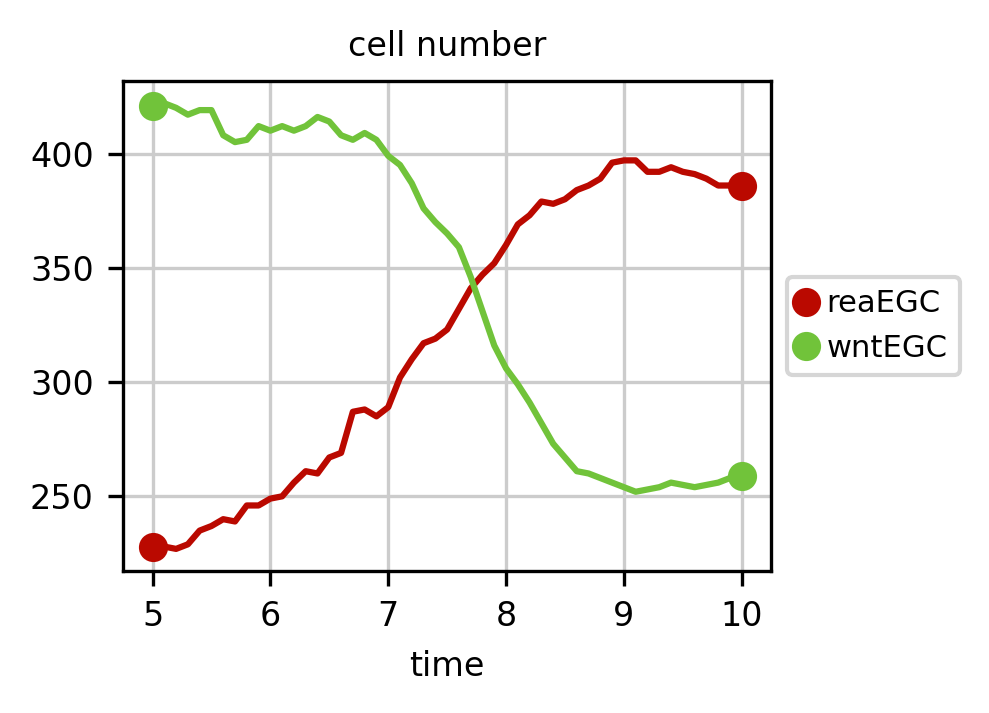

In [ ]:
marker_idx = [0, 50]
plot_all_type_number_time(all_cell_type[30:81], all_time_point[30:81], ['reaEGC', 'wntEGC'], cell_type_color_map, marker_idx=marker_idx, 
                          figsize = (2.77, 4.3/2), save_path=None)

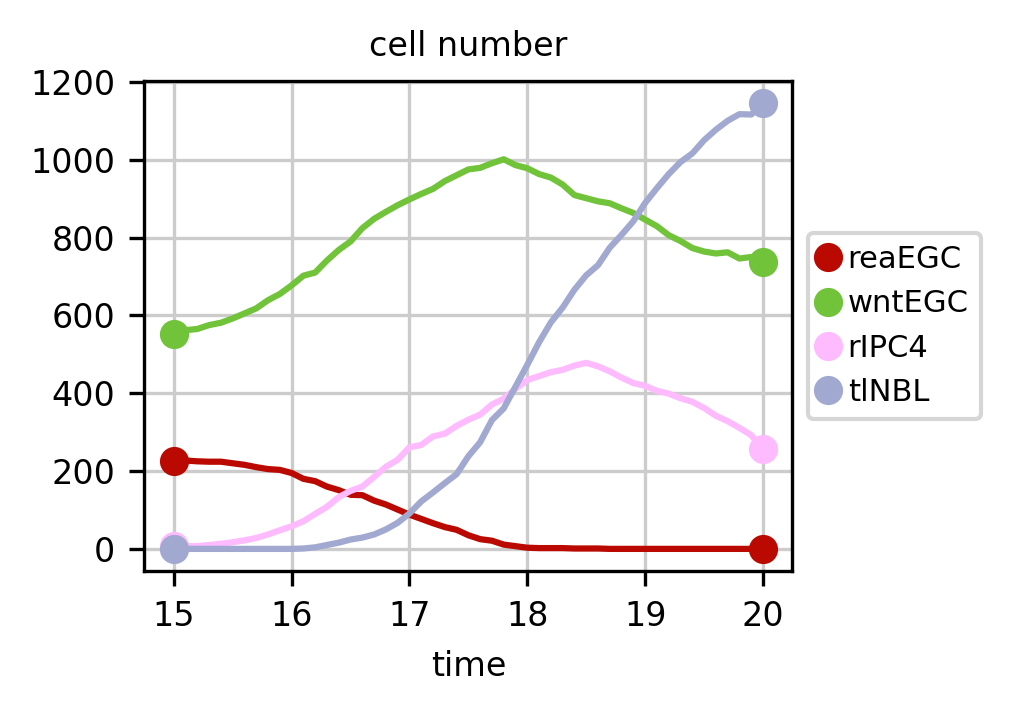

In [ ]:
marker_idx = [0, 50]
plot_all_type_number_time(all_cell_type[130:181], all_time_point[130:181], ['reaEGC', 'wntEGC', 'rIPC4', 'tlNBL'], cell_type_color_map, marker_idx=marker_idx, 
                          figsize = (2.77, 4.3/2), save_path=None)

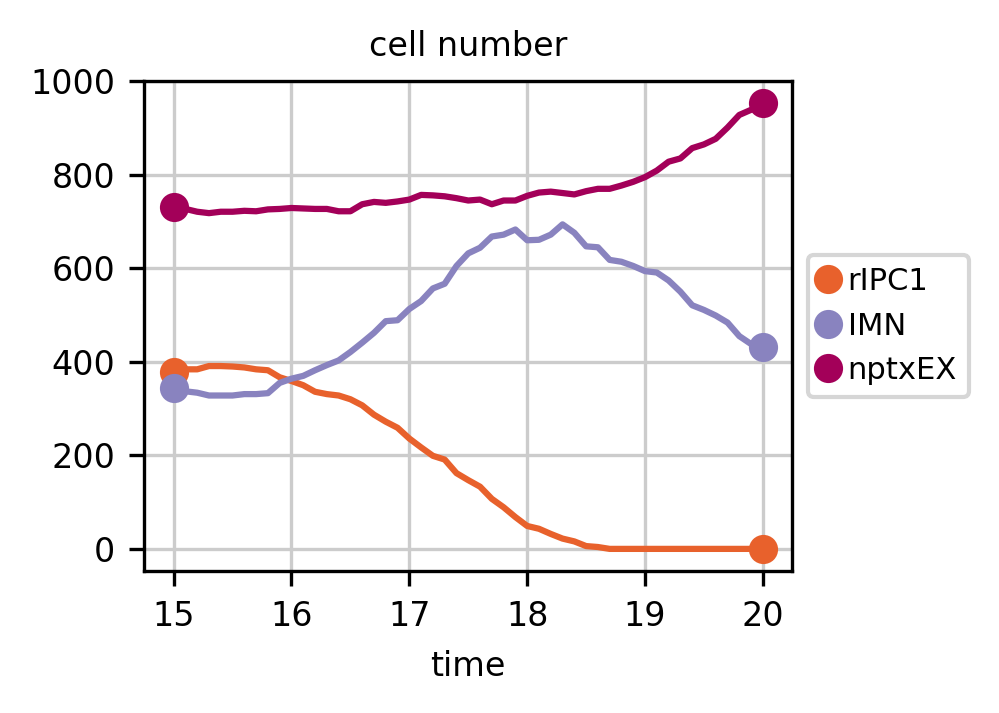

In [ ]:
marker_idx = [0, 50]
plot_all_type_number_time(all_cell_type[130:181], all_time_point[130:181], ['rIPC1', 'IMN', 'nptxEX'], cell_type_color_map, marker_idx=marker_idx, 
                          figsize = (2.77, 4.3/2), save_path=None)

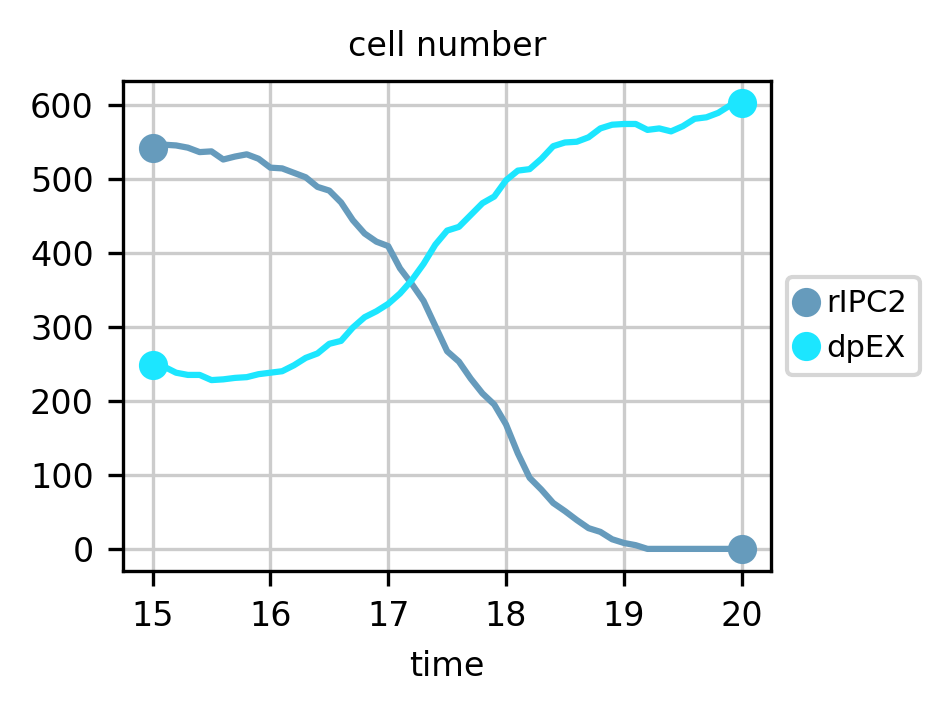

In [ ]:
marker_idx = [0, 50]
plot_all_type_number_time(all_cell_type[130:181], all_time_point[130:181], ['rIPC2', 'dpEX'], cell_type_color_map, marker_idx=marker_idx, 
                          figsize = (2.77, 4.3/2), save_path=None)

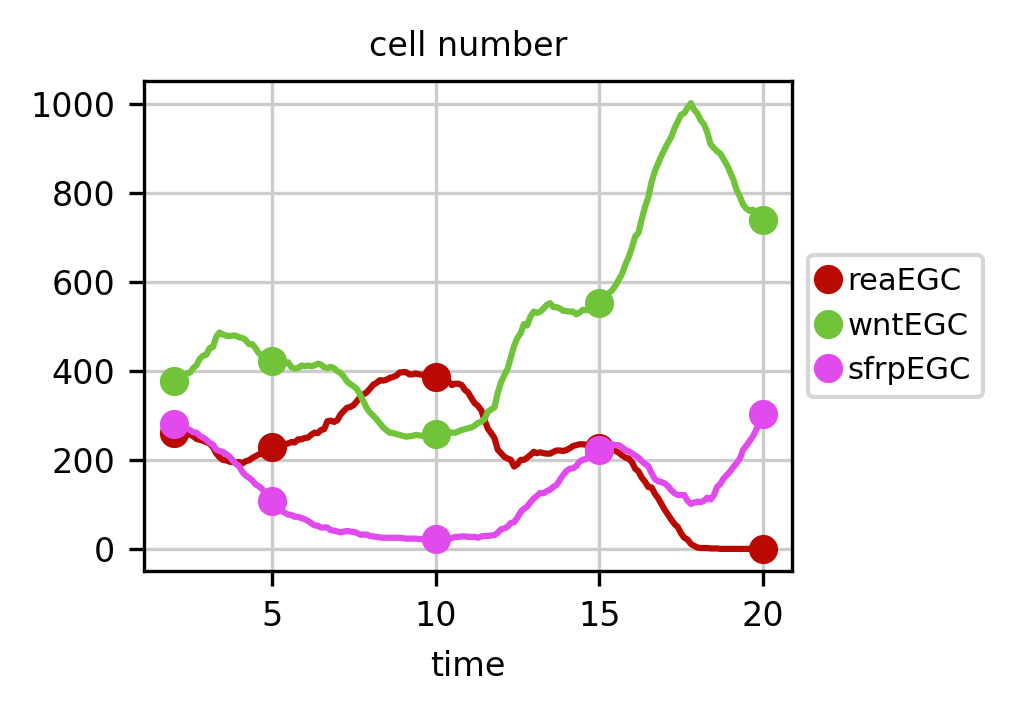

In [ ]:
marker_idx = [0, 30, 80, 130, 180]
plot_all_type_number_time(all_cell_type, all_time_point, ['reaEGC', 'wntEGC','sfrpEGC'], cell_type_color_map, marker_idx=marker_idx, 
                          figsize = (2.77, 4.3/2), save_path=None)

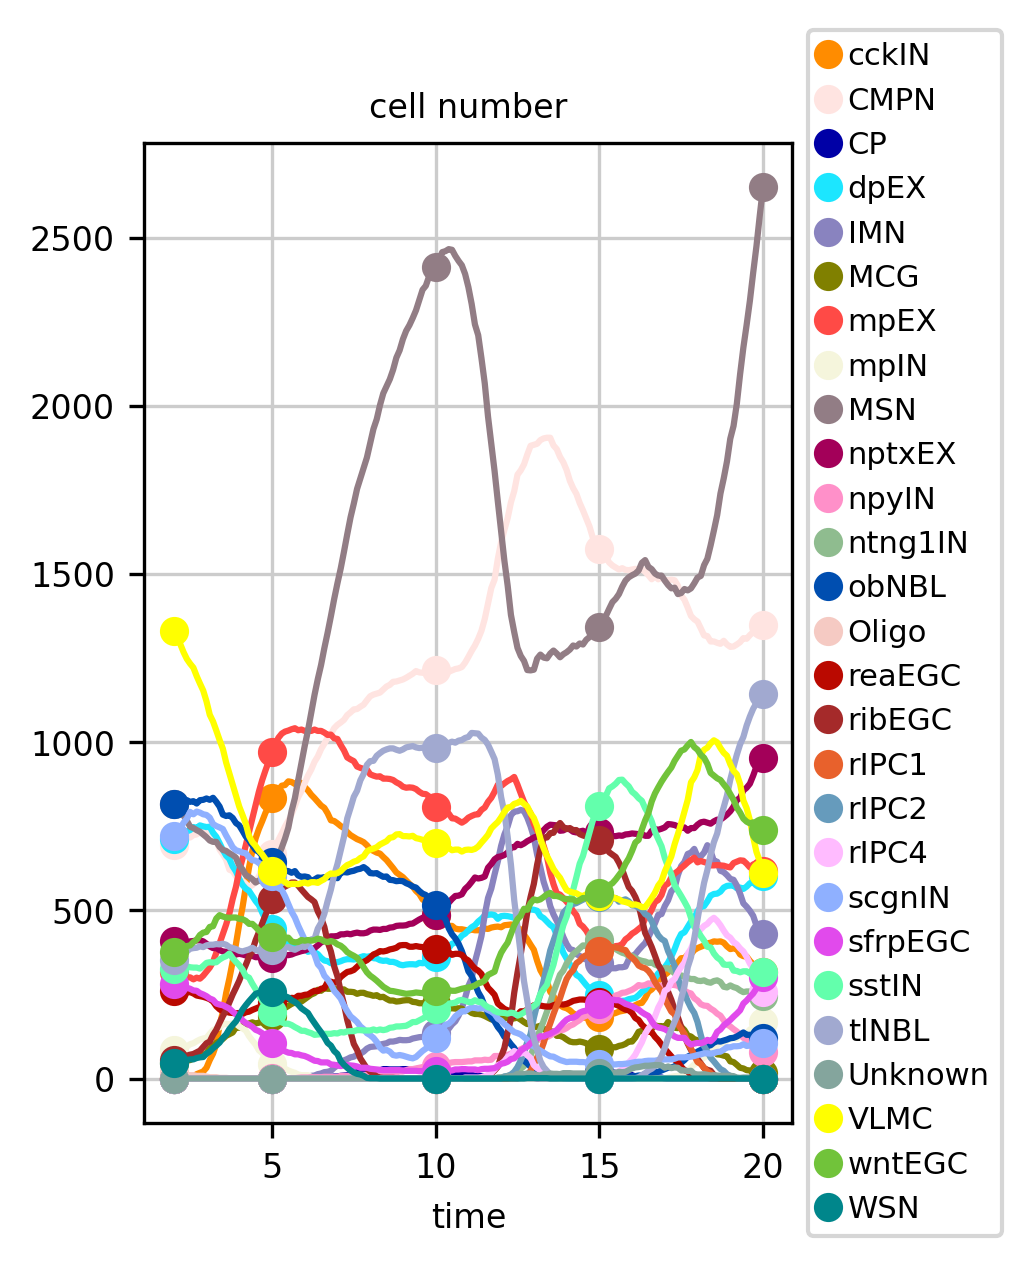

In [ ]:
marker_idx = [0, 30, 80, 130, 180]
plot_all_type_number_time(all_cell_type, all_time_point, cell_type_Annotation, cell_type_color_map, marker_idx=marker_idx, 
                          figsize = (2.77, 4.3), save_path=None)

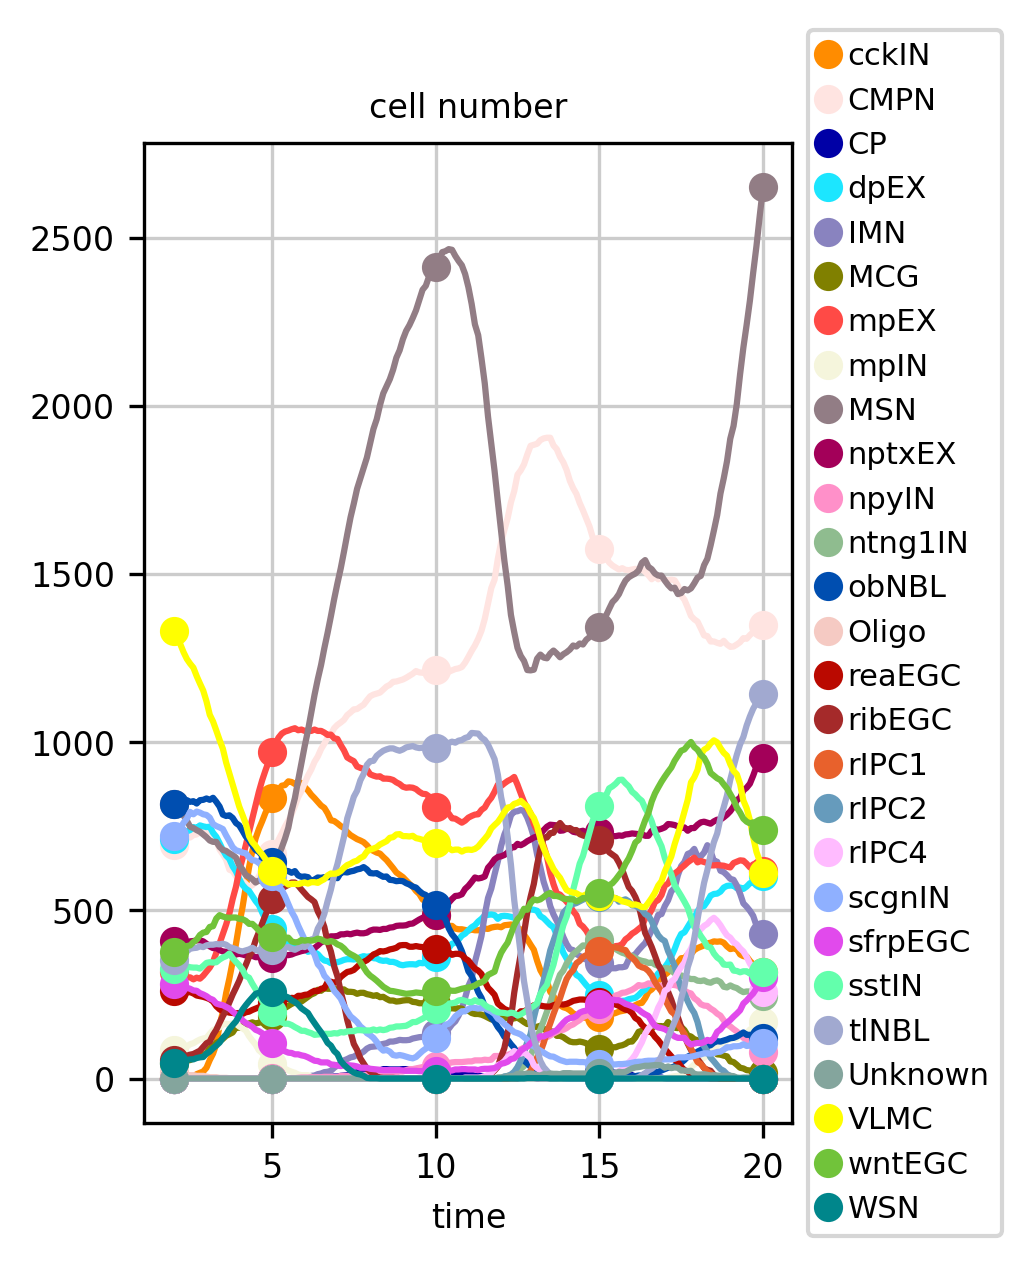

In [ ]:
marker_idx = [0, 30, 80, 130, 180]
plot_all_type_number_time(all_cell_type, all_time_point, cell_type_Annotation, cell_type_color_map, marker_idx=marker_idx, 
                          figsize = (2.77, 4.3), save_path=None)

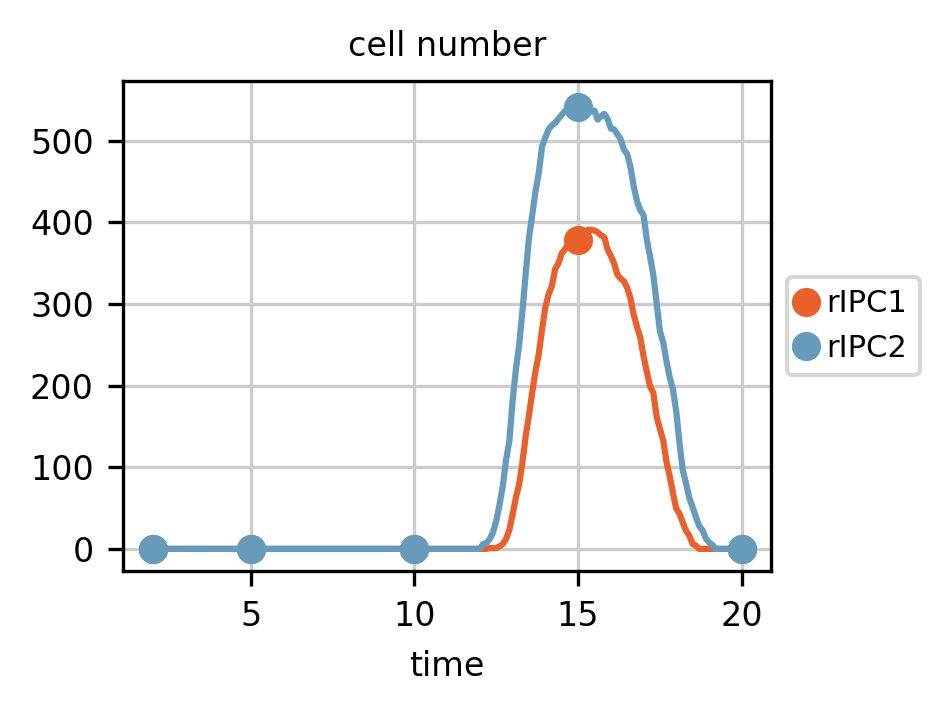

In [ ]:
marker_idx = [0, 30, 80, 130, 180]
plot_all_type_number_time(all_cell_type, all_time_point, ['rIPC1', 'rIPC2'], cell_type_color_map, marker_idx=marker_idx, 
                          figsize = (2.77, 4.3/2), save_path=None)

## Plot all dynamics

In [152]:
def plot_gene_and_move_scanpy(cell_type_time_series_list, z_time_series_list, time_points, gif_name):

    fig = plt.figure(figsize=(6,4))
    ax = fig.add_subplot(111)

    num_frames = len(time_points)

    def update(frame):
        ax.clear()
        adata_cur = ad.AnnData(np.zeros((len(cell_type_time_series_list[frame]),1)))
        adata_cur.obsm['X_spatial_after_stVCR'] = z_time_series_list[frame]
        categories = adata.obs['Annotation'].cat.categories
        adata_cur.obs['Annotation'] = pd.Series(pd.Categorical(cell_type_time_series_list[frame], categories=categories), 
                                                index=adata_cur.obs.index)
        adata_cur.uns['Annotation_colors'] = adata.uns['Annotation_colors']
        

        # scatter = sc.pl.scatter(adata_cur, basis='spatial', color='Annotation',
        #               size = 10, legend_loc= 'right margin', show=True, ax=ax)
        scatter = sc.pl.scatter(adata_cur, basis='spatial_after_stVCR', color='Annotation',
              size = 10, legend_loc= 'none', show=True, ax=ax)
        ax.set_title(f'{time_points[frame] + 2} DPI')
        legend = ax.legend(bbox_to_anchor=(1.0, 0.05), fontsize=8, ncol=7, frameon=False,)
        for handle in legend.legendHandles:
            handle.set_sizes([75])

        return scatter

    animation = FuncAnimation(fig, update, frames=num_frames, interval=50, blit=False)
    if gif_name:
        animation.save(gif_name, fps=2, dpi=150)
    plt.show()

MovieWriter ffmpeg unavailable; using Pillow instead.


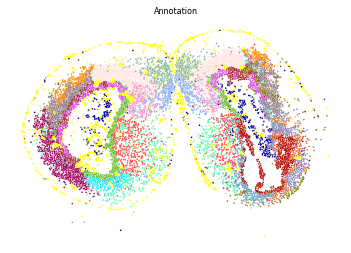

IndexError: list index out of range

In [153]:
plot_gene_and_move_scanpy(all_cell_type, all_spa, all_time_point, gif_name='./ARTISTA.gif')